<img src="https://www.javeriana.edu.co/recursosdb/20125/5571273/escudo-circular.png" alt="Escudo Javeriana" style="float:left;">
<h1>Pontificia Universidad Javeriana</h1>

<h2>Modelado CRISP-DM — Predicción de Cultivos</h2>

### Integrantes:

* 

## Metodología CRISP-DM aplicada a la predicción de aptitud de cultivos

Este cuaderno documenta la aplicación paso a paso del marco **CRISP-DM** para modelar la clasificación de cultivos agrícolas en el departamento de Cundinamarca, Colombia. El dataset proviene de la vista minable construida a partir de datos de satélite (Sentinel-2), clima (IDEAM/CHIRPS), suelo (SoilGrids/IGAC), topografía (DEM) y evidencia agrícola (EVA, UPRA, SIPRA).

**Variable objetivo:** `cultivo_id` — **14 clases** con etiquetado jerárquico de 3 niveles:
- **L1** Monitoreo UPRA (`fuente='monitoreo'`, `confianza=1.0`) — ground truth espacial de Papa y Arroz.
- **L2** EVA municipal (`fuente='eva_municipal'`, `confianza=0.3-0.7`) — cultivo dominante del municipio-semestre, ponderado por `area_cosechada/area_agricola`.
- **L3** No_apto proxy (`fuente='noapto_proxy'`, `confianza=0.4`) — asignado si ≥3 capas SIPRA reportan "No apta" o NDVI_max<0.15.

Catálogo de 14 clases: *Papa, Cana_Panelera, Cafe, Maiz, Platano, Mango, Frijol, Cacao, Arveja, Palma, Banano, Naranja, Otros_cultivos, No_apto*.

**Decisión de diseño clave**: el modelo se entrena con `sample_weight = confianza` para que los L1 dominen el ajuste sin perder cobertura de los L2/L3. La validación usa **`GroupKFold` por `cod_mun`** para evitar fuga espacial (pixeles vecinos del mismo municipio no aparecen en train+test).


---

# 1. Comprensión del Negocio

### 1.1 Objetivo del proyecto
- **Predecir el tipo de cultivo más apto** para cada píxel de 50m × 50m en Cundinamarca usando variables ambientales, edáficas y climáticas.
- **Identificar patrones** entre las condiciones del terreno y los cultivos establecidos.
- **Construir un modelo de clasificación multiclase** interpretable y de alto desempeño que pueda servir como herramienta de apoyo a la planificación agrícola.

### 1.2 Contexto y alcance
- La seguridad alimentaria y la optimización del uso del suelo son prioritarias para Colombia. Conocer qué cultivos son más viables en cada zona permite mejorar la productividad y reducir el riesgo de pérdida de cosechas.
- El dataset integra múltiples fuentes: imágenes satelitales Sentinel-2, datos climáticos IDEAM/CHIRPS, propiedades de suelo SoilGrids/IGAC y modelos digitales de elevación.
- La granularidad es **un registro por píxel-semestre** para 14 clases de cultivo.

### 1.3 Criterios de éxito
- **F1-score macro** ≥ 0.45 en datos de prueba (14 clases con desbalance y etiquetas ruidosas en L2/L3 hace este umbral más realista que el 0.60 anterior de 7 clases).
- **ROC-AUC macro** ≥ 0.80 (one-vs-rest).
- Validación **espacial** (GroupKFold por municipio) para verificar que el modelo generaliza a zonas no vistas.
- Análisis diferenciado de métricas por nivel de confianza (L1 vs L2 vs L3).


---

# 2. Comprensión de los Datos

### Plan de Exploración

En esta fase exploraremos el dataset para:
1. **Validar la estructura**: Confirmar dimensiones y variables disponibles
2. **Evaluar calidad**: Identificar valores faltantes, duplicados y outliers
3. **Analizar distribuciones**: Revisar balance de clases y distribuciones de variables numéricas
4. **Detectar patrones**: Explorar relaciones entre variables predictoras y la variable objetivo
5. **Identificar transformaciones necesarias**: Determinar si requieren escalamiento, codificación o ingeniería de features

### 2.1 Importar Librerías

In [168]:
# Dependencias — asegúrate de tener el entorno del proyecto activo (uv sync o Anaconda).
# Si alguna falta, descomenta la línea apropiada:
%pip install optuna xgboost nbformat


Note: you may need to restart the kernel to use updated packages.


d:\trabajo\agroplus\.venv\Scripts\python.exe: No module named pip


In [169]:
# Supresión de warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Librerías base
import numpy as np
import pandas as pd
import json
import os

# Visualización
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import seaborn as sns

%matplotlib inline
mpl.style.use('ggplot')
sns.set_style("whitegrid")
pylab.rcParams['figure.figsize'] = (12, 8)
plt.rcParams["figure.figsize"] = (12, 6)

# Preprocesamiento
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder,
    LabelEncoder, Normalizer, scale
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Selección y evaluación
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Optimización bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Configuración
np.random.seed(42)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [170]:
# --- Verificar disponibilidad de GPU para XGBoost ---
import xgboost as xgb

try:
    gpu_available = xgb.build_info().get('USE_CUDA', False)
    # Intentar crear una pequeña matriz DMatrix en GPU
    test_data = np.random.rand(100, 10).astype(np.float32)
    test_labels = np.random.randint(0, 3, 100)
    dtest = xgb.DMatrix(test_data, label=test_labels)
    
    # Verificar si CUDA está disponible
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    gpu_present = result.returncode == 0
    
    if gpu_present:
        XGB_DEVICE = 'cuda'
        XGB_TREE_METHOD = 'hist'
        print(f"✅ GPU detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
    else:
        XGB_DEVICE = 'cpu'
        XGB_TREE_METHOD = 'hist'
        print(f"⚠️ GPU no detectada. XGBoost usará device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")
except Exception as e:
    XGB_DEVICE = 'cpu'
    XGB_TREE_METHOD = 'hist'
    print(f"⚠️ Error verificando GPU: {e}. Usando CPU.")

print(f"Configuración XGBoost: device='{XGB_DEVICE}', tree_method='{XGB_TREE_METHOD}'")

✅ GPU detectada. XGBoost usará device='cuda', tree_method='hist'
Configuración XGBoost: device='cuda', tree_method='hist'


### 2.2 Funciones Auxiliares

In [171]:
def plot_distribution(df, var, target, **kwargs):
    """Distribución KDE de una variable por clase objetivo."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    facet = sns.FacetGrid(df, hue=target, aspect=4, row=row, col=col)
    facet.map(sns.kdeplot, var, fill=True)
    facet.set(xlim=(0, df[var].max()))
    facet.add_legend()
    plt.title(f'Distribución de {var} por {target}')

def plot_categories(df, cat, target, **kwargs):
    """Gráfico de barras de una variable categórica vs target."""
    row = kwargs.get('row', None)
    col = kwargs.get('col', None)
    order = sorted(df[cat].unique())
    facet = sns.FacetGrid(df, row=row, col=col)
    facet.map(sns.barplot, cat, target, order=order)
    facet.add_legend()

def plot_correlation_map(df, figsize=(16, 14)):
    """Mapa de calor de correlaciones entre variables numéricas."""
    num = df.select_dtypes(include="number")
    if num.shape[1] == 0:
        raise ValueError("No hay columnas numéricas.")
    corr = num.corr()
    _, ax = plt.subplots(figsize=figsize)
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(
        corr, cmap=cmap, square=True,
        cbar_kws={"shrink": 0.9}, ax=ax,
        annot=True, annot_kws={"fontsize": 7}, fmt=".2f"
    )
    plt.title('Mapa de Correlaciones')
    plt.tight_layout()

def plot_class_balance(y, title='Distribución de Clases'):
    """Visualizar el balance de clases del target."""
    counts = pd.Series(y).value_counts()
    fig, ax = plt.subplots(figsize=(10, 5))
    counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(counts)))
    for i, (val, name) in enumerate(zip(counts.values, counts.index)):
        ax.text(i, val + counts.max()*0.01, f'{val:,}', ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('Número de registros')
    ax.set_xlabel('Clase (cultivo_id)')
    plt.tight_layout()

print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


### 2.3 Cargar los Datos

In [172]:
# --- Configuración de rutas locales ---
# El notebook se ejecuta desde `modelado/` — los datos están en `../vista_minable/`.
import os
from pathlib import Path

# Directorio raíz del proyecto (sube un nivel desde modelado/)
PROJECT_ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'modelado' \
                                        else Path(os.getcwd())
DATA_DIR = PROJECT_ROOT / 'vista_minable'

print(f"Directorio del proyecto: {PROJECT_ROOT}")
print(f"Directorio de datos:     {DATA_DIR}")
assert DATA_DIR.exists(), f"No se encontró {DATA_DIR}. Ejecuta 04_construir_vista_minable primero."


Directorio del proyecto: d:\trabajo\agroplus
Directorio de datos:     d:\trabajo\agroplus\vista_minable


In [173]:
# Cargar la vista minable
DATA_PATH = DATA_DIR / 'vista_minable_full.parquet'
df_raw = pd.read_parquet(DATA_PATH)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas")
print(f"\nDistribucion por fuente (L1/L2/L3):")
print(df_raw['fuente'].value_counts())
print(f"\nDistribucion de confianza:")
print(df_raw['confianza'].describe())


Dataset cargado: 5,415,961 filas x 55 columnas

Distribucion por fuente (L1/L2/L3):
fuente
eva_municipal    3390312
noapto_proxy     1459620
monitoreo         566029
Name: count, dtype: int64

Distribucion de confianza:
count   5415961.0000
mean          0.5728
std           0.1986
min           0.3000
25%           0.4000
50%           0.5564
75%           0.7000
max           1.0000
Name: confianza, dtype: float64


In [174]:
# Cargar catalogo de cultivos (mapeo nombre -> cultivo_id)
CATALOGO_PATH = DATA_DIR / 'catalogo_cultivos.json'
with open(CATALOGO_PATH, 'r', encoding='utf-8') as f:
    catalogo = json.load(f)

# Catalogo ordenado por id (MODEL_CLASSES tiene el orden estable del proyecto)
inv_catalogo = {v: k for k, v in catalogo.items()}
print(f"Catalogo de {len(catalogo)} clases:")
for i in sorted(inv_catalogo):
    print(f"  {i:2d}: {inv_catalogo[i]}")


Catalogo de 14 clases:
   0: Papa
   1: Cana_Panelera
   2: Cafe
   3: Maiz
   4: Platano
   5: Mango
   6: Frijol
   7: Cacao
   8: Arveja
   9: Palma
  10: Banano
  11: Naranja
  12: Otros_cultivos
  13: No_apto


In [175]:
# Vista general del DataFrame
df_raw.head(10)

,pixel_id,x,y,semestre,cod_mun,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,s2_ndvi_max,s2_ndvi_std,s2_gndvi_media,s2_gndvi_max,s2_gndvi_std,s2_msavi_media,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo,cultivo_id,confianza,fuente,rendimiento_tha
0,0,1107022.7366,1137622.5453,2020A,0,3009.6982,12.5241,20.0455,5.5000,97.5000,53.2000,25.8000,10.6000,29.0000,30.0000,40.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,0.6507,-0.8811,0.4730,-0.6050,-0.0890,-1.3440,71.6516,372.1031,0.5355,0.7516,0.1087,0.5041,0.6270,0.0657,0.3156,0.5122,0.1162,0.0111,0.2292,0.1733,0.3359,0.5101,0.1037,1.2550,-1.4321,0.7516,96.3826,3.0764,No_apto,13,0.4000,noapto_proxy,NaN
1,1,1060221.1597,1137572.5366,2020A,0,2174.9927,13.8300,19.6552,5.4000,75.1000,46.8000,23.7000,9.4000,40.0000,31.0000,28.0000,3.0000,1.0000,1.0000,1.0000,3.0000,2.0000,0.5284,0.8365,-0.5480,3.6222,4.3000,3.0504,71.6516,730.4546,0.5947,0.8010,0.2586,0.5242,0.7299,0.2450,0.4136,0.5691,0.1726,-0.1860,-0.1262,0.0495,0.4130,0.5531,0.1688,1.2496,-2.0888,0.8010,107.0441,4.8579,No_apto,13,0.4000,noapto_proxy,NaN
2,2,1062471.2355,1137572.5366,2020A,0,2325.3787,11.0770,20.5380,5.3000,83.6000,39.5000,25.7000,9.7000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.5255,0.9380,0.3466,2.7806,3.4366,2.2582,71.6516,733.9651,0.5619,0.6604,0.1205,0.5396,0.6305,0.1129,0.2708,0.2974,0.0268,-0.0288,-0.0057,0.0199,0.3019,0.3325,0.0317,1.1784,-2.0776,0.6604,101.1445,5.2322,No_apto,13,0.4000,noapto_proxy,NaN
3,4,1071271.5320,1137572.5366,2020A,0,2059.6421,0.6440,23.8345,5.6000,50.9000,42.6000,24.4000,10.3000,33.0000,31.0000,35.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4658,0.9470,-0.3213,4.4441,5.0226,4.0970,71.6516,730.7438,0.6330,0.7346,0.0618,0.5935,0.6931,0.0673,0.3890,0.4479,0.0388,-0.0889,-0.0517,0.0355,0.4066,0.4594,0.0342,0.9256,-1.9294,0.7346,113.9380,5.4381,No_apto,13,0.4000,noapto_proxy,NaN
4,5,1071821.5506,1137572.5366,2020A,0,2060.9927,1.5970,21.4907,5.4000,64.8000,44.0000,22.6000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4747,0.9181,0.3964,4.3788,4.9520,4.0370,71.6516,731.0130,0.7071,0.8185,0.1178,0.6292,0.7388,0.1105,0.5296,0.6003,0.0768,-0.2170,-0.1662,0.0425,0.5185,0.5747,0.0646,0.9151,-1.9126,0.8185,127.2868,5.4874,No_apto,13,0.4000,noapto_proxy,NaN
5,6,1071921.5539,1137572.5366,2020A,0,2063.5684,1.5206,19.8580,5.4000,64.4000,44.2000,22.3000,10.3000,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4714,0.8045,-0.5939,4.3658,4.9380,4.0235,71.6516,731.0619,0.7043,0.7764,0.0973,0.6202,0.7079,0.0982,0.4863,0.5231,0.0510,-0.1939,-0.1667,0.0278,0.4860,0.5175,0.0449,0.9145,-1.9095,0.7764,126.7796,5.4926,No_apto,13,0.4000,noapto_proxy,NaN
6,7,1077771.7511,1137572.5366,2020A,0,2232.4365,21.7495,24.3270,5.5000,92.5000,43.0000,22.6000,10.3000,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.5472,0.7914,0.6113,2.4908,2.9984,2.1302,71.6516,690.0074,-1665.8527,0.8659,3726.6968,-1665.9232,0.8011,3726.6653,-1666.0718,0.5865,3726.5986,-1666.7773,-0.2338,3726.2832,-1666.0785,0.5608,3726.5959,0.8681,-1.8122,0.8659,-299853.5000,5.8126,No_apto,13,0.4000,noapto_proxy,NaN
7,8,1090322.1739,1137572.5366,2020A,0,2936.6338,56.5498,20.3787,5.5000,99.0000,50.5000,29.2000,9.4000,32.0000,34.0000,32.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.6775,0.1265,-0.9920,-0.8975,-0.5517,-1.2487,71.6516,574.0226,0.7279,0.8313,0.1263,0.6702,0.7804,0.1191,0.4119,0.4730,0.0539,-0.2616,-0.1968,0.0432,0.4275,0.4800,0.0501,0.6969,-1.6584,0.8313,131.0287,6.4788,No_apto,13,0.4000,noapto_proxy,NaN
8,9,1091222.2042,1137572.5366,2020A,0,2807.0730,36.2494,20.1568,

In [176]:
# Información general de tipos y nulos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5415961 entries, 0 to 5415960
Data columns (total 55 columns):
 #   Column             Dtype  
---  ------             -----  
 0   pixel_id           int64  
 1   x                  float64
 2   y                  float64
 3   semestre           object 
 4   cod_mun            int32  
 5   elevacion          float32
 6   pendiente          float32
 7   twi                float32
 8   sg_phh2o           float32
 9   sg_soc             float32
 10  sg_nitrogen        float32
 11  sg_cec             float32
 12  sg_bdod            float32
 13  sg_clay            float32
 14  sg_sand            float32
 15  sg_silt            float32
 16  igac_fertilidad    float32
 17  igac_fosforo       float32
 18  igac_ph            float32
 19  igac_potasio       float32
 20  igac_vocacion      float32
 21  piso_termico       float32
 22  indice_fertilidad  float32
 23  aspecto_sin        float32
 24  aspecto_cos        float32
 25  temperatura_media 

In [177]:
# Descripción estadística de variables numéricas
df_raw.describe()

,pixel_id,x,y,cod_mun,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,s2_ndvi_max,s2_ndvi_std,s2_gndvi_media,s2_gndvi_max,s2_gndvi_std,s2_msavi_media,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo_id,confianza,rendimiento_tha
count,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5368075.0000,5368075.0000,5368075.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5415961.0000,5149645.0000,5415961.0000,5415961.0000,5415961.0000,5415853.0000,5415853.0000,5415853.0000,5415853.0000,5415961.0000,5384333.0000,5384333.0000,5415961.0000,5384334.0000,5384334.0000,5415961.0000,5384333.0000,5384333.0000,5415961.0000,5384327.0000,5384327.0000,5415961.0000,5384333.0000,5384333.0000,5415961.0000,5415853.0000,5415961.0000,5384333.0000,5415961.0000,5415853.0000,5415961.0000,5415961.0000,3956341.0000
mean,2930006.4243,1013528.6411,1033170.3140,21859.2316,2509.6111,15.4834,5.6257,5.5019,77.5305,49.2734,27.8027,10.2892,31.5189,34.1700,32.9227,2.6083,1.0656,1.3179,1.2976,2.5863,2.1145,0.6008,-0.0399,-0.1339,-0.9912,0.5244,-2.4133,79.2165,719.4253,-2612.7708,0.7043,3367.2078,-2612.7588,0.6345,3367.1541,-2612.9307,0.4619,3367.1272,-2613.9019,-0.0439,3367.5291,-2612.9224,0.4614,3367.1294,2.9378,-0.0076,0.7043,-472913.2500,5.2694,5.7370,0.5728,17.1642
std,1704823.1421,39593.8583,45738.3810,8677.1241,740.3149,13.8025,5.9574,0.3944,19.6124,8.6775,4.6189,1.2154,3.8513,5.3016,3.5481,1.0593,0.3788,0.6193,0.5397,2.9011,0.5944,0.1293,0.7203,0.6790,6.7555,7.0812,6.4216,7.3612,317.1861,2093.5681,0.1426,1869.3789,2093.5476,0.1142,1869.3862,2093.5295,0.1459,1869.3451,2093.4426,0.1435,1868.9735,2093.5308,0.1240,1869.3511,2.2765,0.9981,0.1426,386204.0938,2.9149,6.0699,0.1986,8.9813
min,0.0000,918116.3718,904282.0684,0.0000,194.7007,0.0000,2.3195,0.1000,0.1000,0.1000,0.1000,0.1000,17.0000,17.0000,21.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,-1.0000,-1.0000,-16.2086,-14.3792,-19.8179,61.8401,0.0000,-8332.6670,-1.0000,0.0000,-8332.6670,-1.0000,0.0000,-8332.5400,-0.2438,0.0000,-8332.6104,-0.6619,0.0000,-8332.5342,-0.2071,0.0000,0.1937,-2.1172,-1.0000,-1799820.0000,0.0000,0.0000,0.3000,0.2800
25%,1454759.0000,983918.5889,1000698.7935,25178.0000,2436.7683,5.2994,2.5889,5.3000,65.2000,44.8000,25.8000,9.5000,29.0000,31.0000,30.0000,2.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.5515,-0.7630,-0.7996,-5.1851,-3.9885,-6.4162,71.9533,518.1088,-3332.7227,0.6443,3726.5518,-3332.7249,0.5908,3726.5522,-3332.8562,0.3648,3726.4836,-3333.1709,-0.1451,3726.3071,-3332.8391,0.3856,3726.4929,1.2413,-0.7988,0.6443,-599887.0000,3.0815,0.0000,0.4000,13.9000
50%,2914238.0000,1010319.4784,1035104.7618,25407.0000,2655.2051,13.0624,3.1297,5.5000,75.4000,49.5000,28.0000,10.3000,32.0000,34.0000,33.0000,3.0000,1.0000,1.0000,1.0000,0.0000,2.0000,0.6115,-0.1103,-0.2333,-2.9770,-1.5431,-4.1234,80.1888,631.2406,-1666.2095,0.7334,3726.6738,-1666.1998,0.6549,3726.6431,-1666.3470,0.4655,3726.5898,-1666.7319,-0.0675,3726.4087,-1666.3276,0.4703,3726.5884,2.1306,-0.1109,0.7334,-299906.9375,4.7630,2.0000,0.5564,19.5000
75%,4371374.0000,1038820.4387,1067110.3137,25769.0000,2974.6631,21.1851,4.4312,5.7000,89.1000,54.3000,30.6000,11.1000,34.0000,38.0000,35.0000,3.0000,1.0000,2.0000,2.0000,6.0000,2.0000,0.6736,0.6876,0.5228,0.5026,2.4964,-0.8557,85.2972,810.4251,-1665.9010,0.8010,4713.8765,-1665.9707,0.7063,4713.8467,-1666.0822,0.5615,4713.7612,-1666.4800,0.0388,4713.5244,-1666.0874,0.5459,4713.7666,4.0513,0.7318,0.8010,-299862.5625,6.7319,13.0000,0.7000,21.5000
max,5999910.0000,1113772.9640,1137622.5453,25899.0000,

### 2.4 Validación de la Estructura

In [178]:
print("==" * 30)
print("RESUMEN DE LA ESTRUCTURA")
print("==" * 30)
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"\nColumnas por tipo:")
for dtype, count in df_raw.dtypes.value_counts().items():
    print(f"  {dtype}: {count}")
print(f"\nColumnas:\n{list(df_raw.columns)}")

RESUMEN DE LA ESTRUCTURA
Filas: 5,415,961
Columnas: 55

Columnas por tipo:
  float32: 47
  object: 3
  float64: 2
  int64: 1
  int32: 1
  int16: 1

Columnas:
['pixel_id', 'x', 'y', 'semestre', 'cod_mun', 'elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'igac_fertilidad', 'igac_fosforo', 'igac_ph', 'igac_potasio', 'igac_vocacion', 'piso_termico', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'temperatura_max', 'temperatura_min', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 's2_savi_media', 's2_savi_max', 's2_savi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_max', 'ndvi_integral', 'indice_aridez', 'cultivo', 'cultivo_id', 'confianza', 'fuente', 'rendimiento_tha']


### 2.5 Evaluación de Calidad de los Datos

In [179]:
# Valores faltantes
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct
}).sort_values('pct_missing', ascending=False)

print("Valores faltantes por columna:")
print(missing_df[missing_df['n_missing'] > 0].to_string())
print(f"\nTotal de filas duplicadas: {df_raw.duplicated().sum():,}")

Valores faltantes por columna:
                   n_missing  pct_missing
rendimiento_tha      1459620      26.9500
piso_termico          266316       4.9200
sg_clay                47886       0.8800
sg_sand                47886       0.8800
sg_silt                47886       0.8800
s2_ndvi_media          31628       0.5800
s2_gndvi_media         31627       0.5800
s2_msavi_max           31628       0.5800
s2_bsi_media           31634       0.5800
s2_ndvi_max            31628       0.5800
s2_msavi_media         31628       0.5800
ndvi_max               31628       0.5800
s2_savi_max            31628       0.5800
s2_savi_media          31628       0.5800
s2_bsi_max             31634       0.5800
s2_gndvi_max           31627       0.5800
humedad_media            108       0.0000
temperatura_media        108       0.0000
temperatura_max          108       0.0000
temperatura_min          108       0.0000
amplitud_termica         108       0.0000
indice_aridez            108       0.0000

To

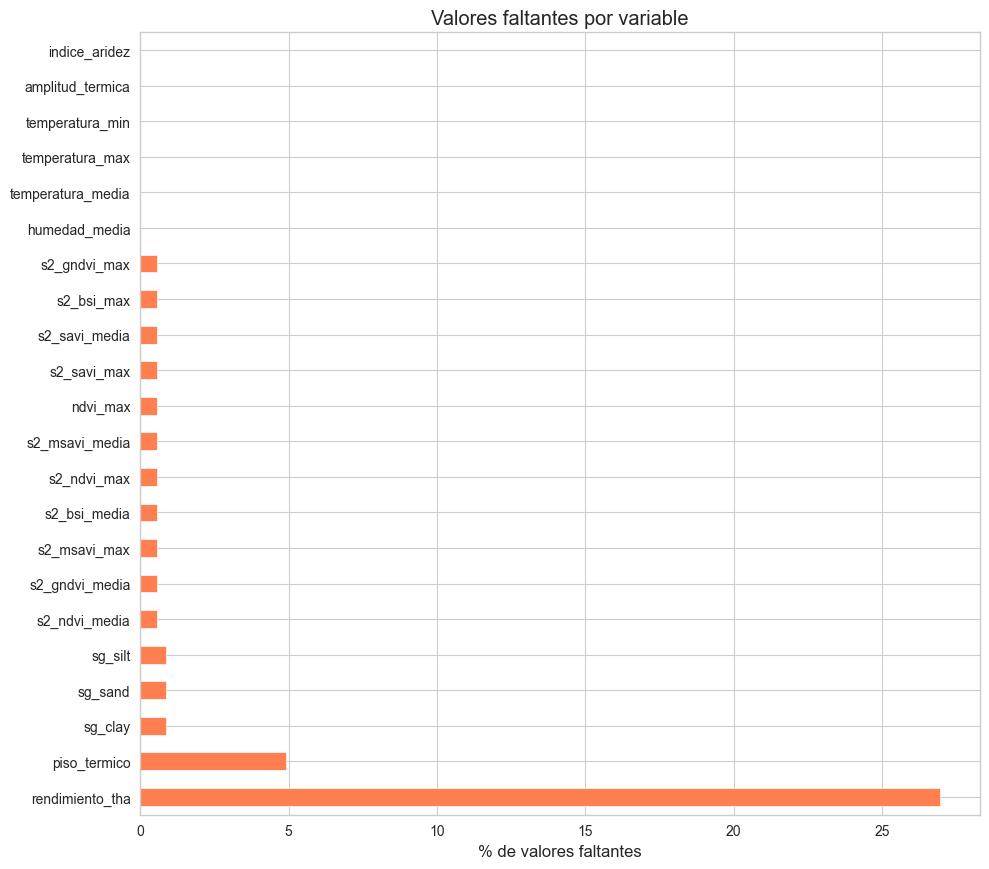

In [180]:
# Visualización de valores faltantes
missing_nonzero = missing_df[missing_df['n_missing'] > 0]
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_nonzero)*0.4)))
    missing_nonzero['pct_missing'].plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Valores faltantes por variable')
    plt.tight_layout()
else:
    print("No se encontraron valores faltantes significativos.")

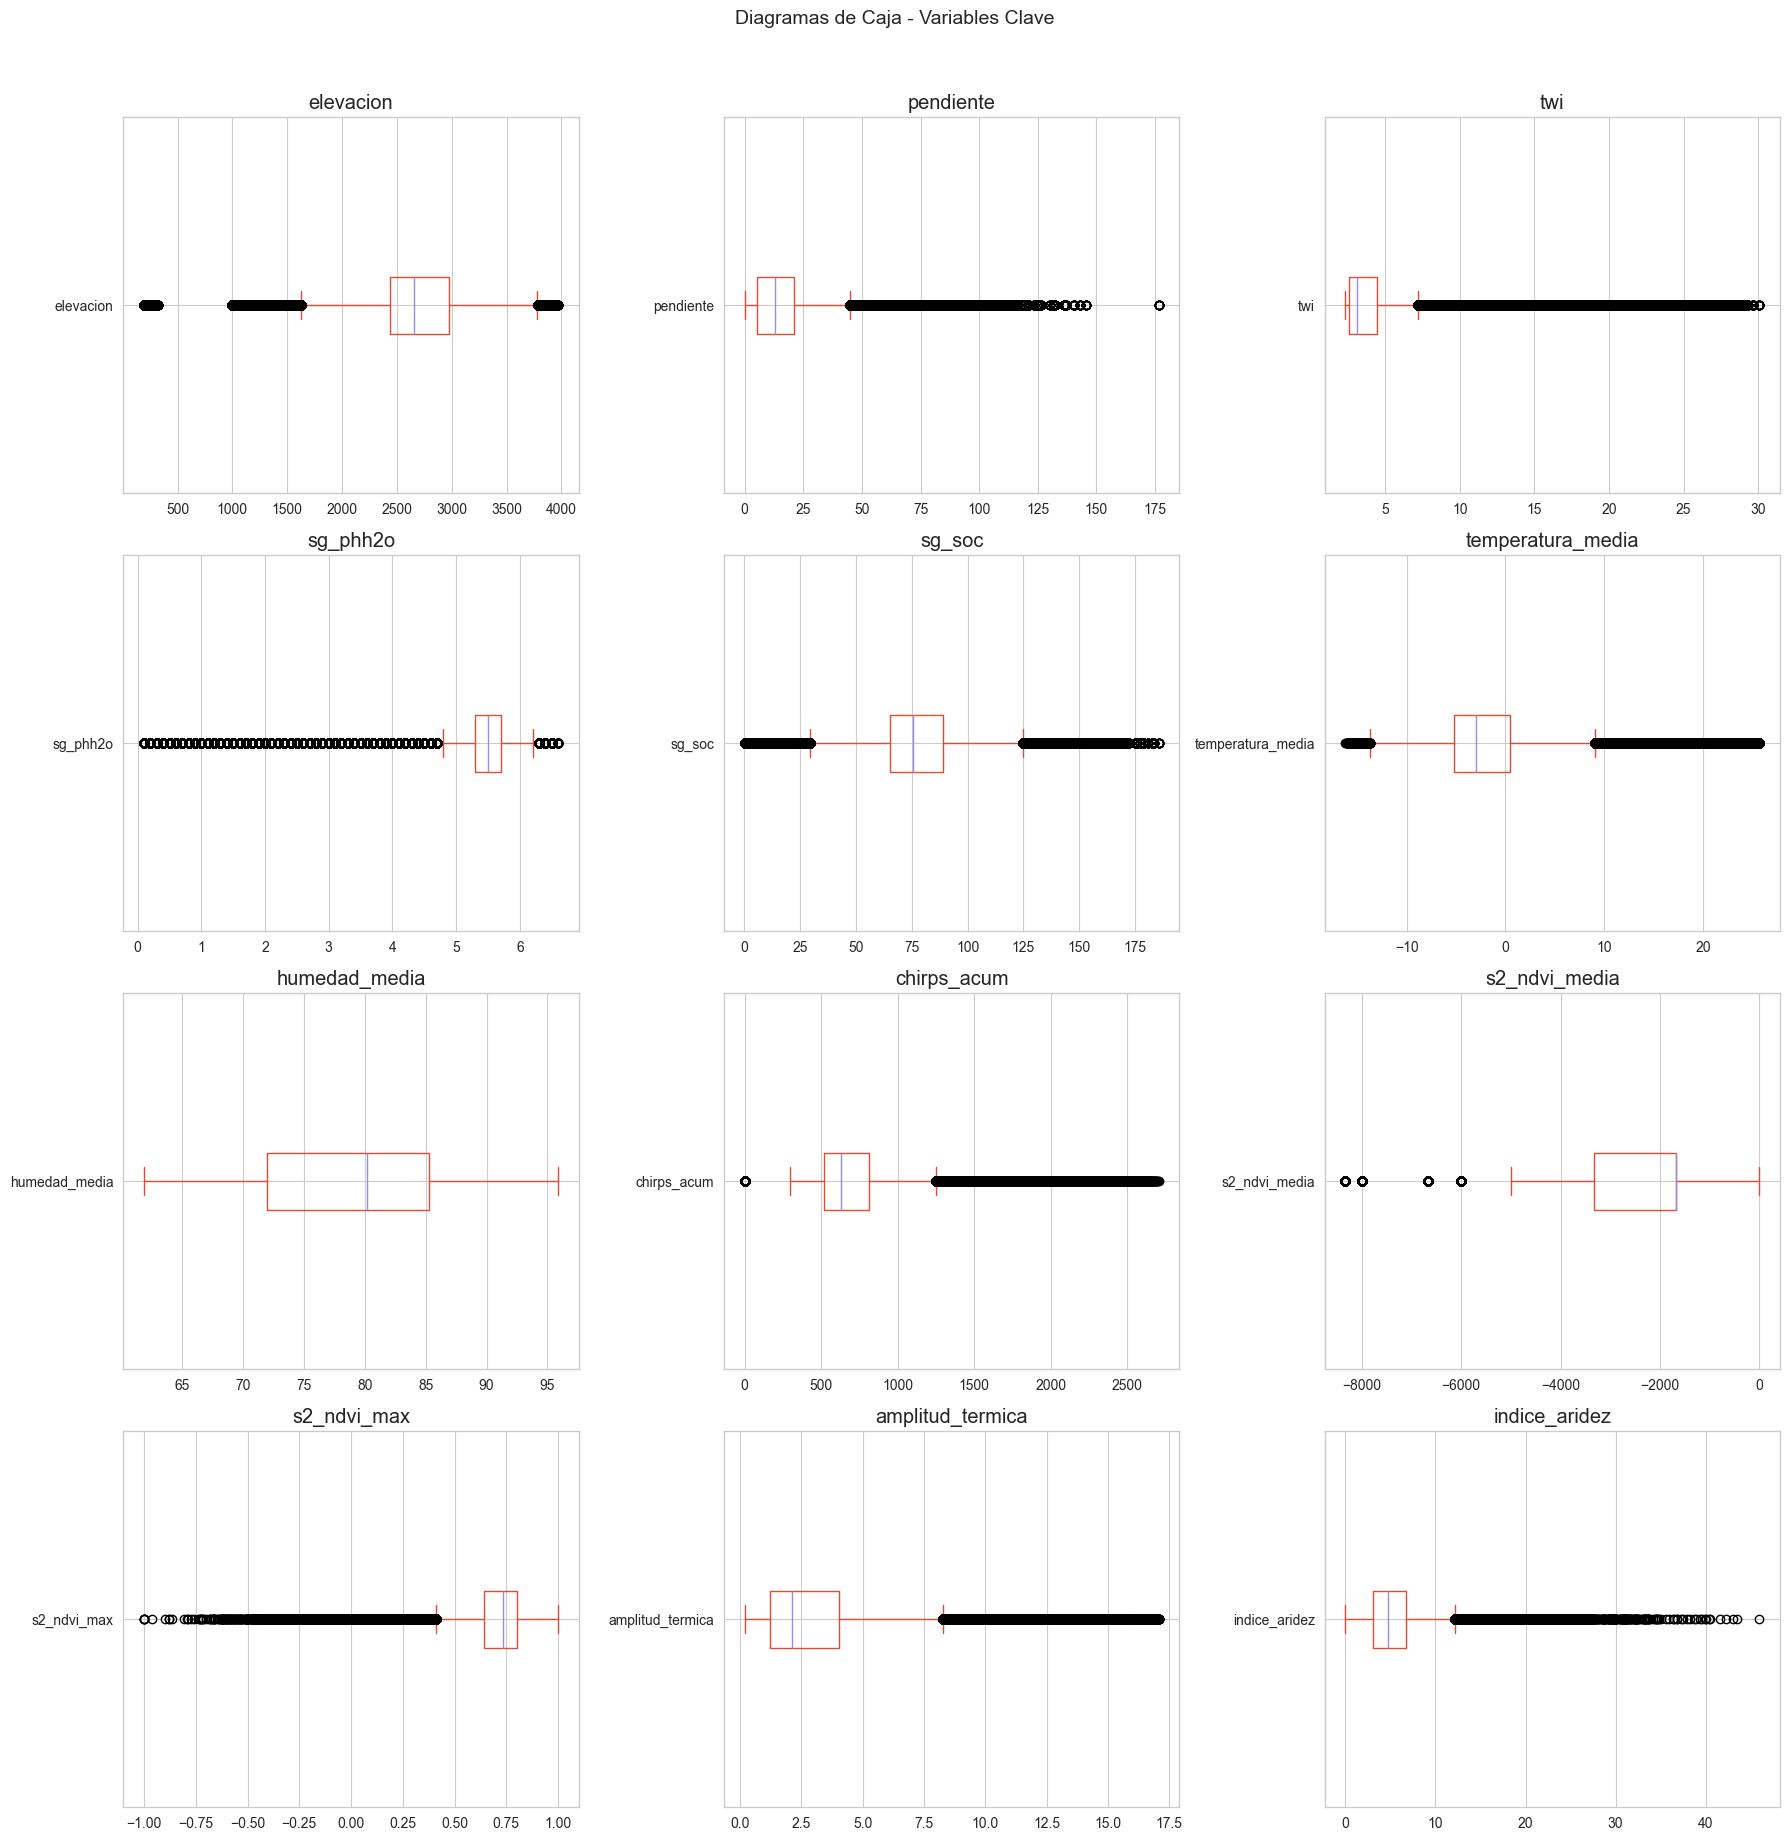

In [181]:
# Detección de outliers con diagramas de caja para variables numéricas clave
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
# Excluir ids y coordenadas
exclude = ['pixel_id', 'cultivo_id']
plot_cols = [c for c in numeric_cols if c not in exclude]

# Seleccionar un subconjunto de variables clave para visualización
key_vars = ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc',
            'temperatura_media', 'humedad_media', 'chirps_acum',
            's2_ndvi_media', 's2_ndvi_max', 'amplitud_termica', 'indice_aridez']
key_vars = [v for v in key_vars if v in df_raw.columns]

fig, axes = plt.subplots(len(key_vars)//3, 3, figsize=(18, len(key_vars)*1.5))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().plot(kind='box', ax=axes[i], vert=False)
        axes[i].set_title(col)
plt.suptitle('Diagramas de Caja - Variables Clave', y=1.02, fontsize=14)
plt.tight_layout()

### 2.6 Análisis de Distribuciones

In [182]:
# Distribución del target - Balance de clases
target_col = 'cultivo_id'
print("Distribución de clases (cultivo_id):")
class_dist = df_raw[target_col].value_counts().sort_index()
class_pct = (df_raw[target_col].value_counts(normalize=True).sort_index() * 100).round(2)

for cls in class_dist.index:
    name = inv_catalogo.get(cls, f"Clase_{cls}")
    print(f"  {cls:2d} ({name:<16}): {class_dist[cls]:>10,} ({class_pct[cls]:>6.2f}%)")

print(f"\nRatio de desbalance: {class_dist.max() / max(class_dist.min(), 1):.0f}:1")
print(f"\nFuentes del target (L1/L2/L3):")
print(df_raw.groupby('fuente')['confianza'].agg(['count', 'mean']).round(3))


Distribución de clases (cultivo_id):
   0 (Papa            ):  2,604,695 ( 48.09%)
   1 (Cana_Panelera   ):     57,367 (  1.06%)
   2 (Cafe            ):    122,582 (  2.26%)
   3 (Maiz            ):    128,390 (  2.37%)
   4 (Platano         ):      9,497 (  0.18%)
   5 (Mango           ):     12,263 (  0.23%)
   6 (Frijol          ):     86,109 (  1.59%)
   7 (Cacao           ):     26,682 (  0.49%)
   8 (Arveja          ):      2,760 (  0.05%)
   9 (Palma           ):     85,455 (  1.58%)
  10 (Banano          ):     15,839 (  0.29%)
  12 (Otros_cultivos  ):    804,702 ( 14.86%)
  13 (No_apto         ):  1,459,620 ( 26.95%)

Ratio de desbalance: 944:1

Fuentes del target (L1/L2/L3):
                 count   mean
fuente                       
eva_municipal  3390312 0.5760
monitoreo       566029 1.0000
noapto_proxy   1459620 0.4000


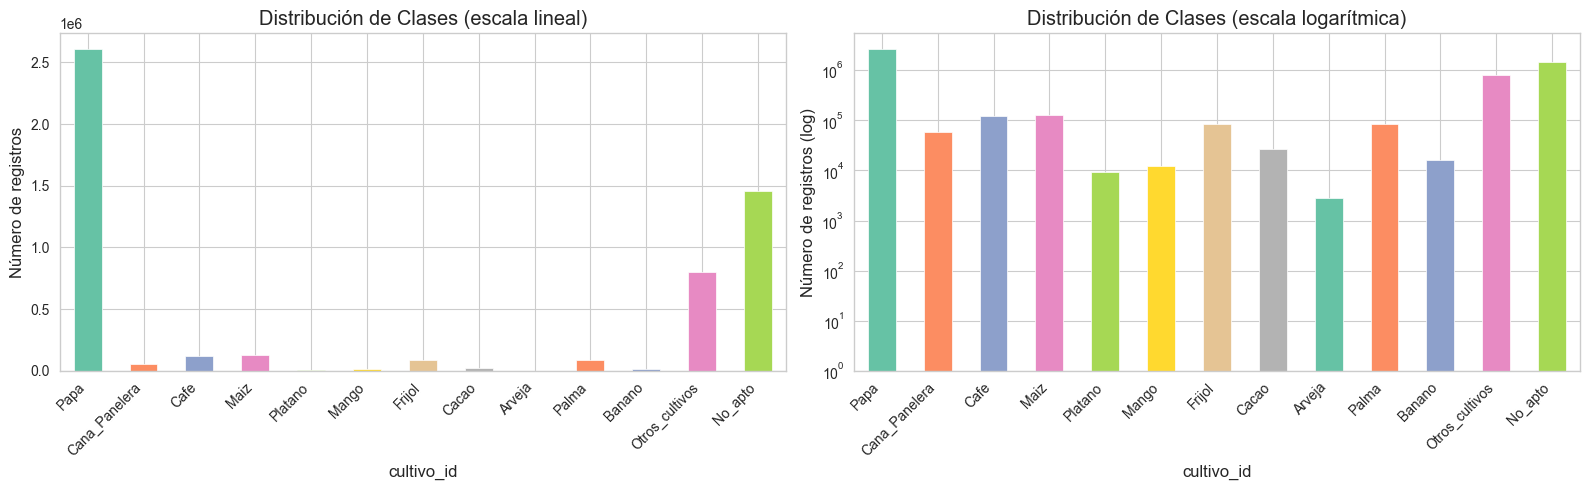

In [183]:
# Visualización del balance de clases
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

labels = [inv_catalogo.get(c, f'C{c}') for c in class_dist.index]

class_dist.plot(kind='bar', ax=ax1, color=sns.color_palette("Set2", len(class_dist)))
ax1.set_title('Distribución de Clases (escala lineal)')
ax1.set_xlabel('cultivo_id')
ax1.set_ylabel('Número de registros')
ax1.set_xticklabels(labels, rotation=45, ha='right')

class_dist.plot(kind='bar', ax=ax2, color=sns.color_palette("Set2", len(class_dist)), log=True)
ax2.set_title('Distribución de Clases (escala logarítmica)')
ax2.set_xlabel('cultivo_id')
ax2.set_ylabel('Número de registros (log)')
ax2.set_xticklabels(labels, rotation=45, ha='right')

plt.tight_layout()


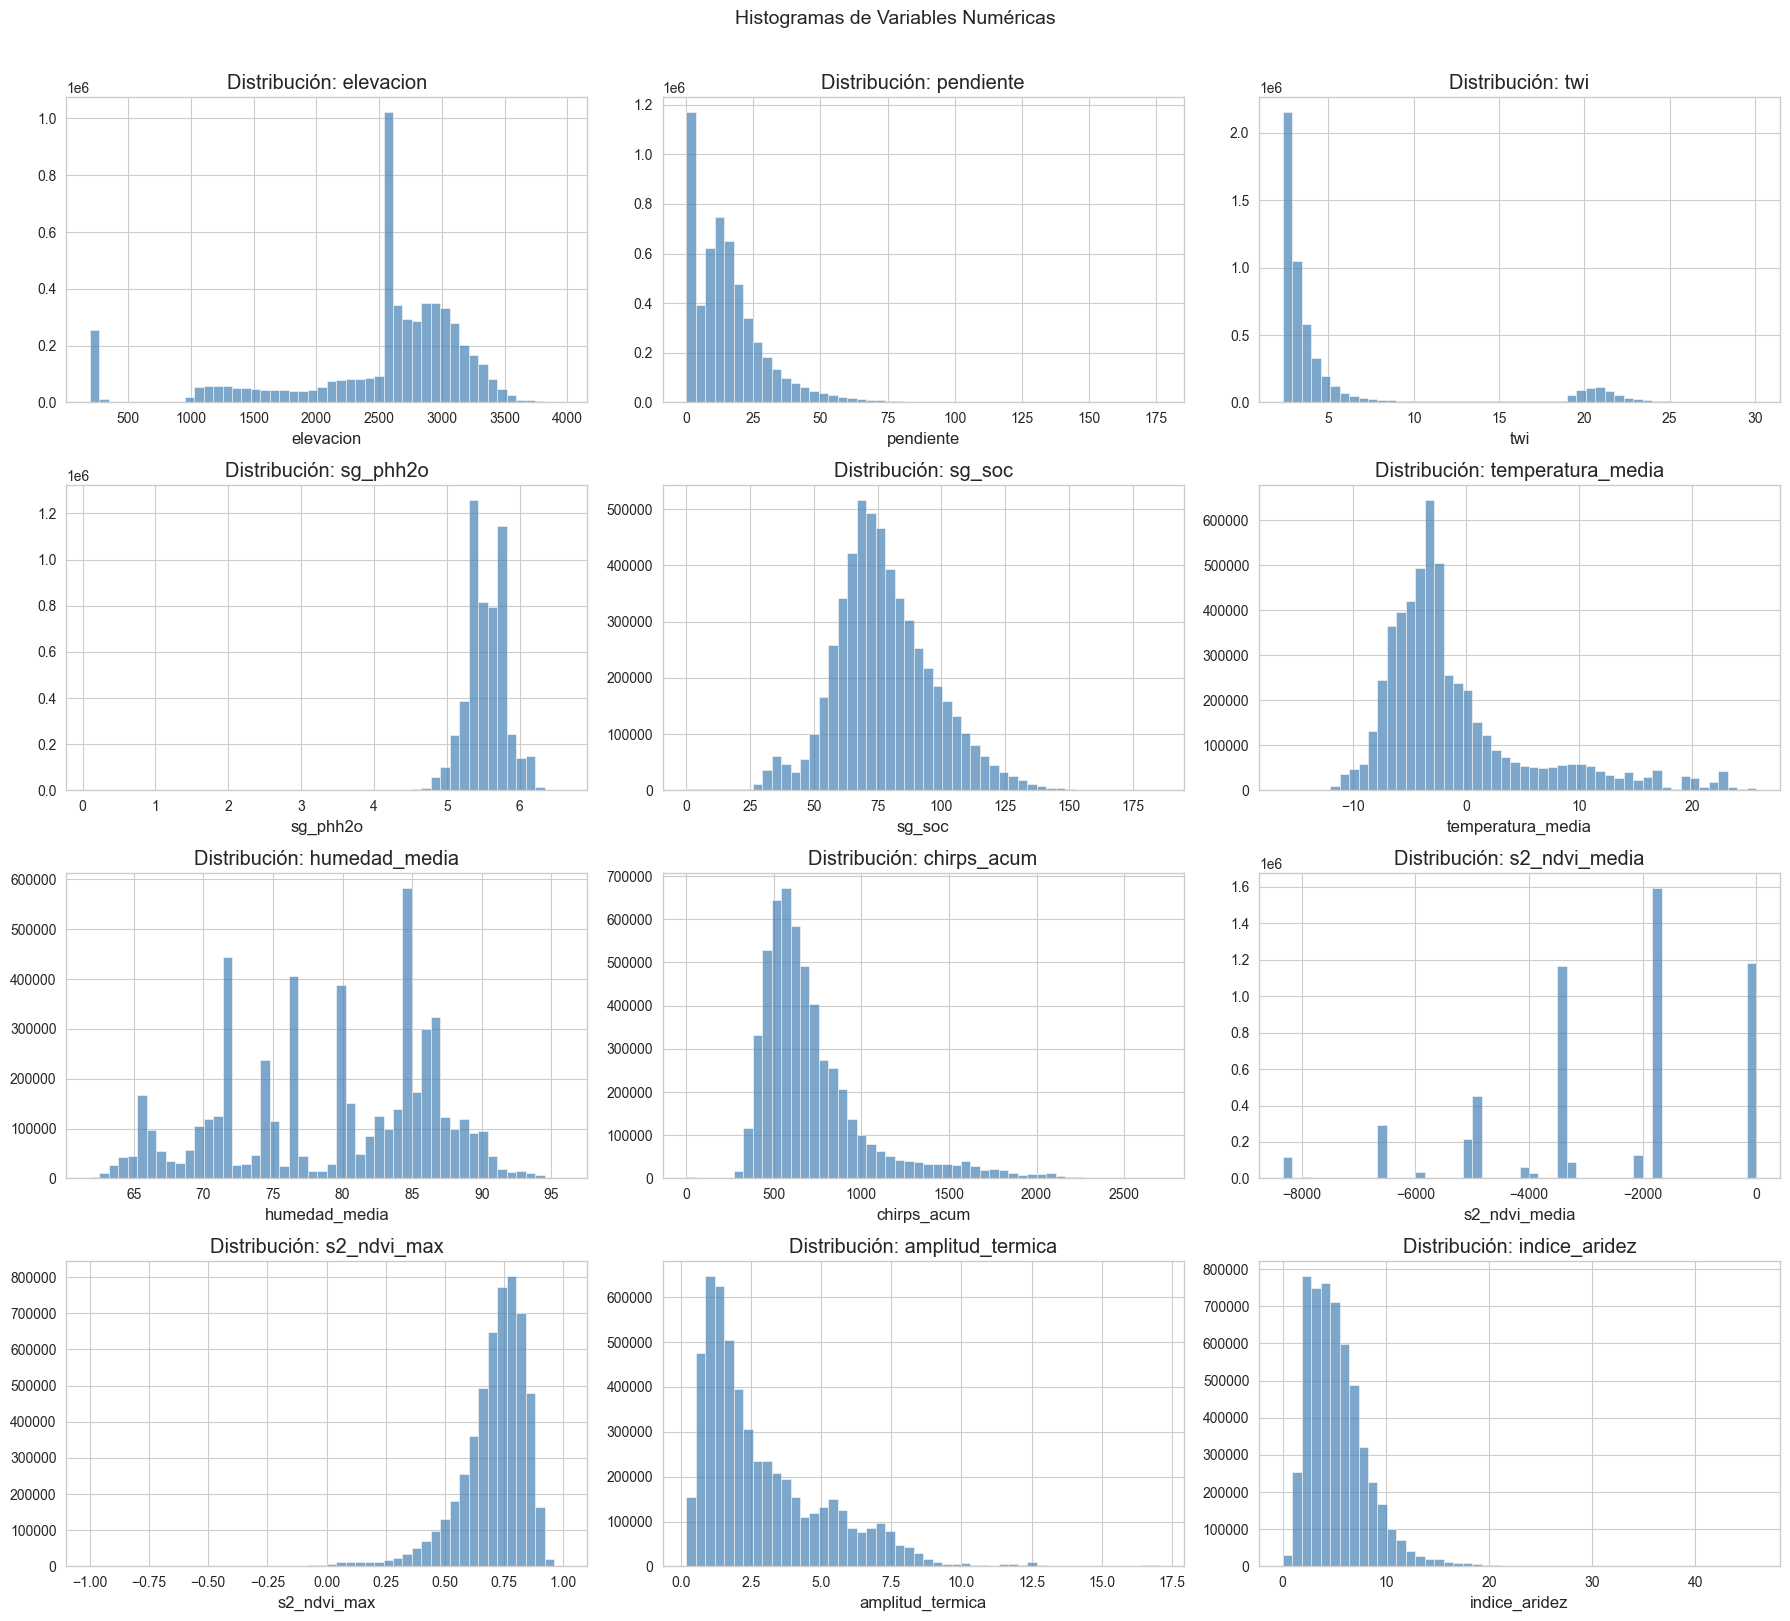

In [184]:
# Histogramas de variables numéricas clave
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    if i < len(axes):
        df_raw[col].dropna().hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(f'Distribución: {col}')
        axes[i].set_xlabel(col)
plt.suptitle('Histogramas de Variables Numéricas', y=1.01, fontsize=14)
plt.tight_layout()

### 2.7 Detección de Patrones - Correlaciones

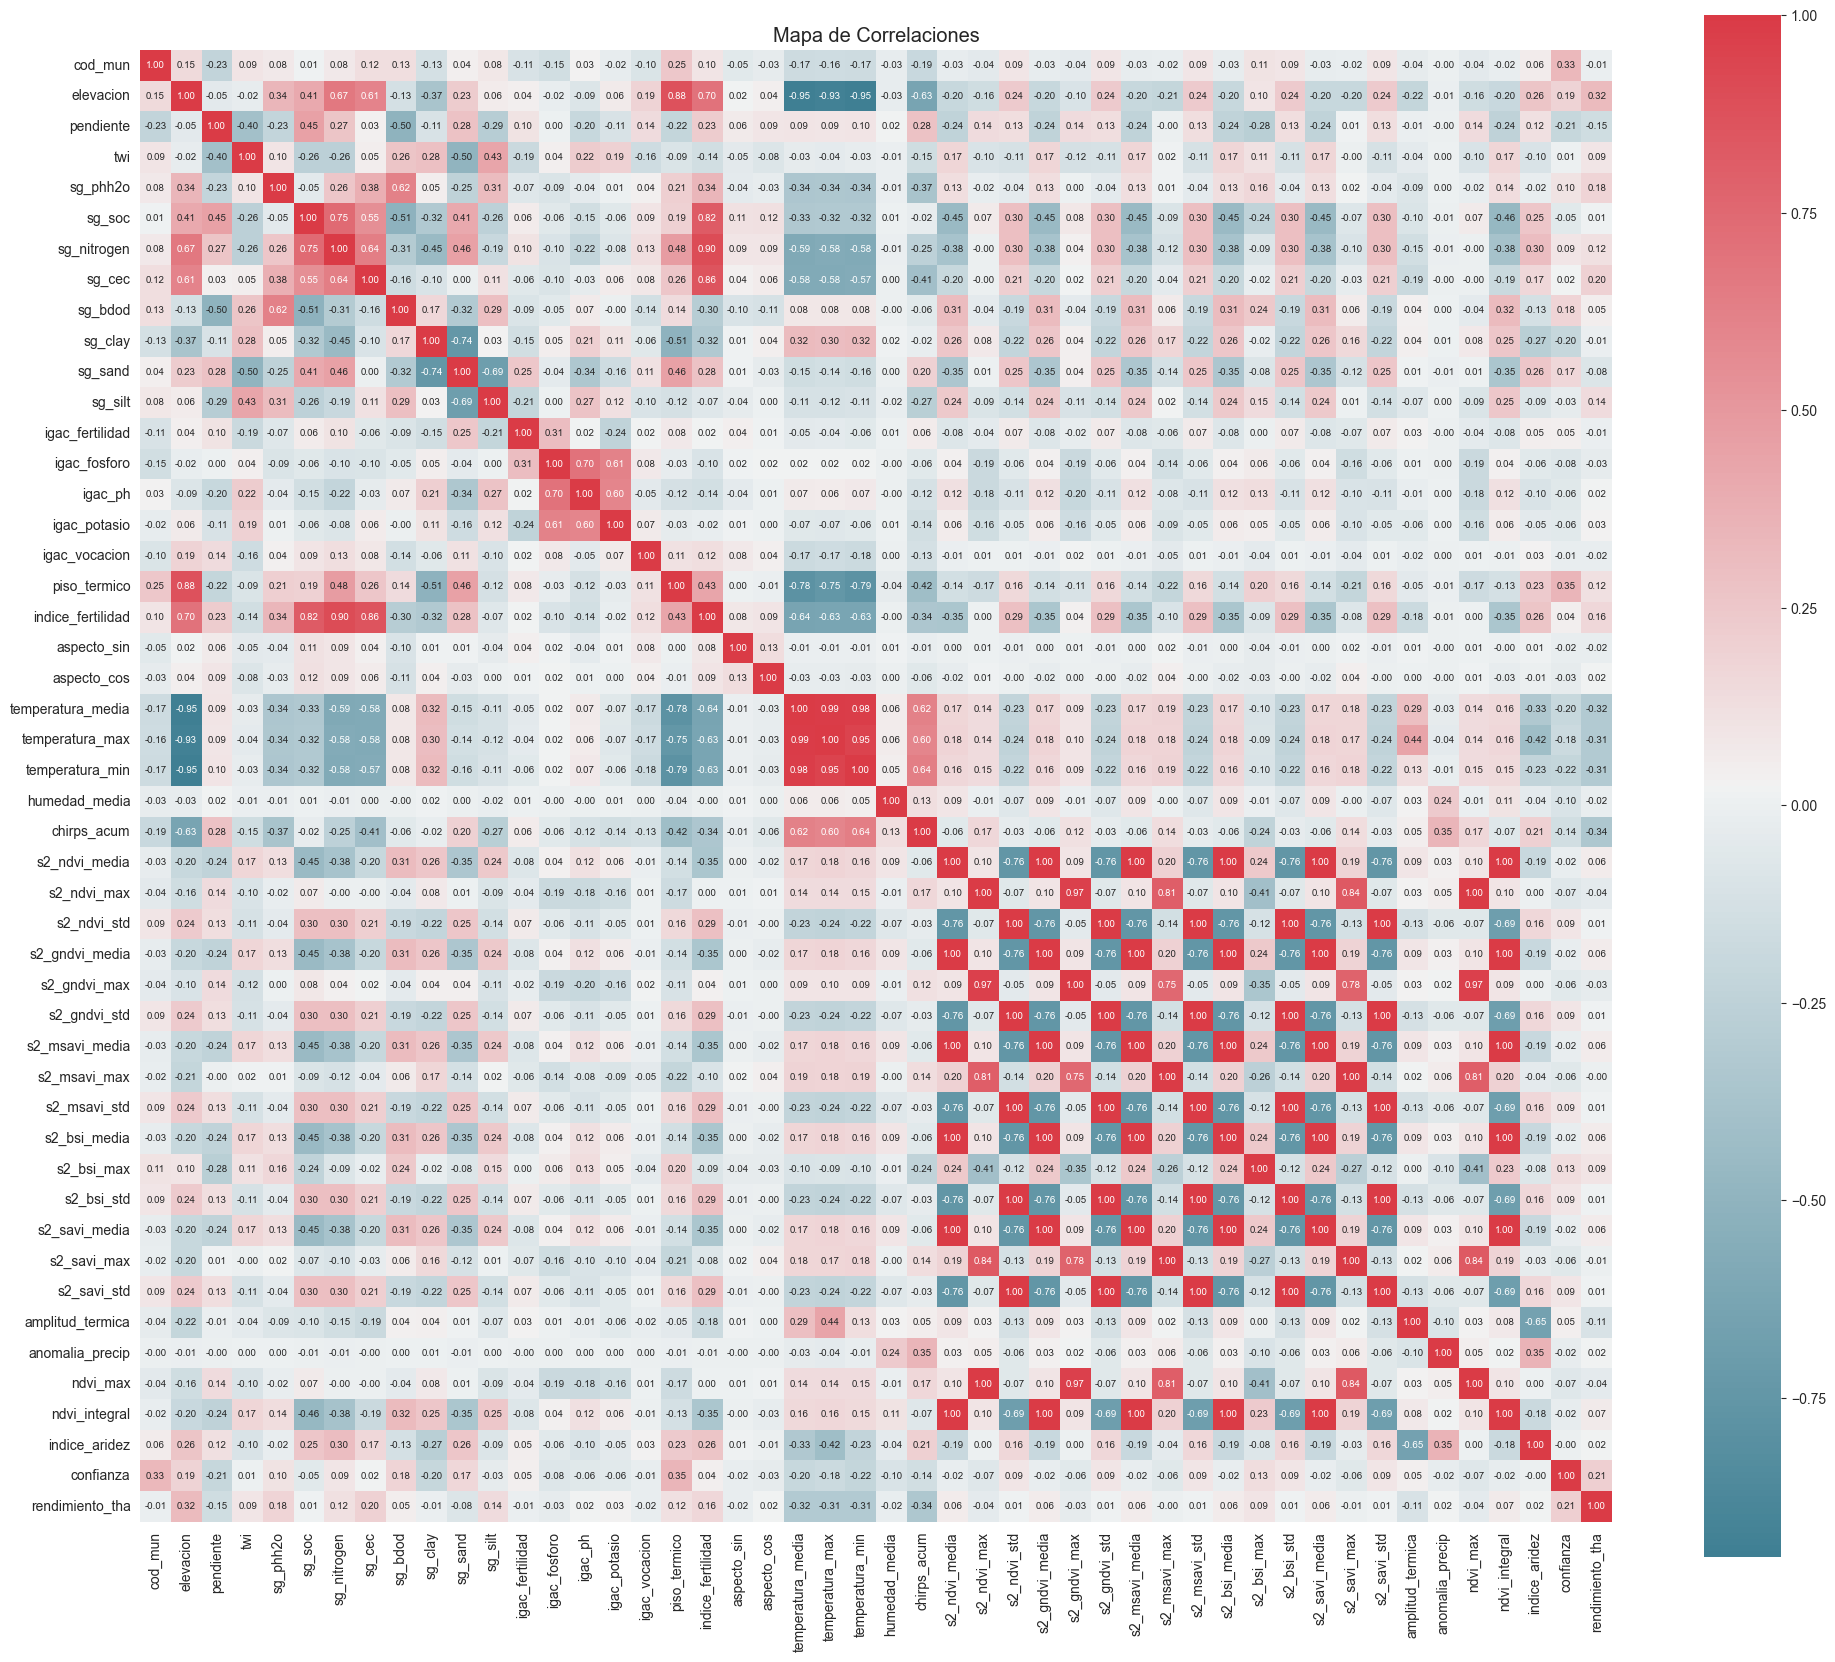

In [185]:
# Mapa de correlación de variables numéricas (sin IDs ni coordenadas)
corr_cols = [c for c in numeric_cols if c not in ['pixel_id', 'x', 'y', 'cultivo_id']]
corr_cols = [c for c in corr_cols if df_raw[c].notna().sum() > 0]  # solo cols con datos
plot_correlation_map(df_raw[corr_cols], figsize=(20, 18))

Top 15 variables más correlacionadas con cultivo_id:
  confianza: -0.5629
  cod_mun: -0.4823
  temperatura_min: +0.3687
  elevacion: -0.3662
  temperatura_media: +0.3503
  rendimiento_tha: -0.3472
  chirps_acum: +0.3357
  piso_termico: -0.3303
  temperatura_max: +0.3284
  indice_fertilidad: -0.2401
  humedad_media: +0.2392
  sg_nitrogen: -0.2390
  sg_cec: -0.2194
  sg_clay: +0.1959
  sg_sand: -0.1454


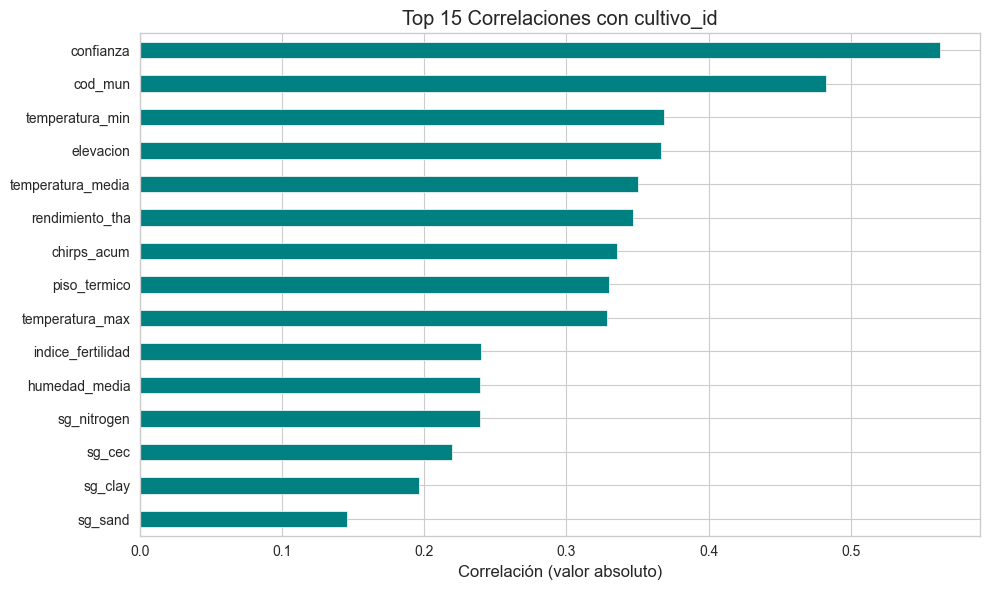

In [186]:
# Correlaciones más fuertes con el target
if target_col in df_raw.columns:
    correlations = df_raw[corr_cols + [target_col]].corr()[target_col].drop(target_col)
    top_corr = correlations.abs().sort_values(ascending=False).head(15)
    print("Top 15 variables más correlacionadas con cultivo_id:")
    for var in top_corr.index:
        print(f"  {var}: {correlations[var]:+.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    top_corr.sort_values().plot(kind='barh', ax=ax, color='teal')
    ax.set_title('Top 15 Correlaciones con cultivo_id')
    ax.set_xlabel('Correlación (valor absoluto)')
    plt.tight_layout()

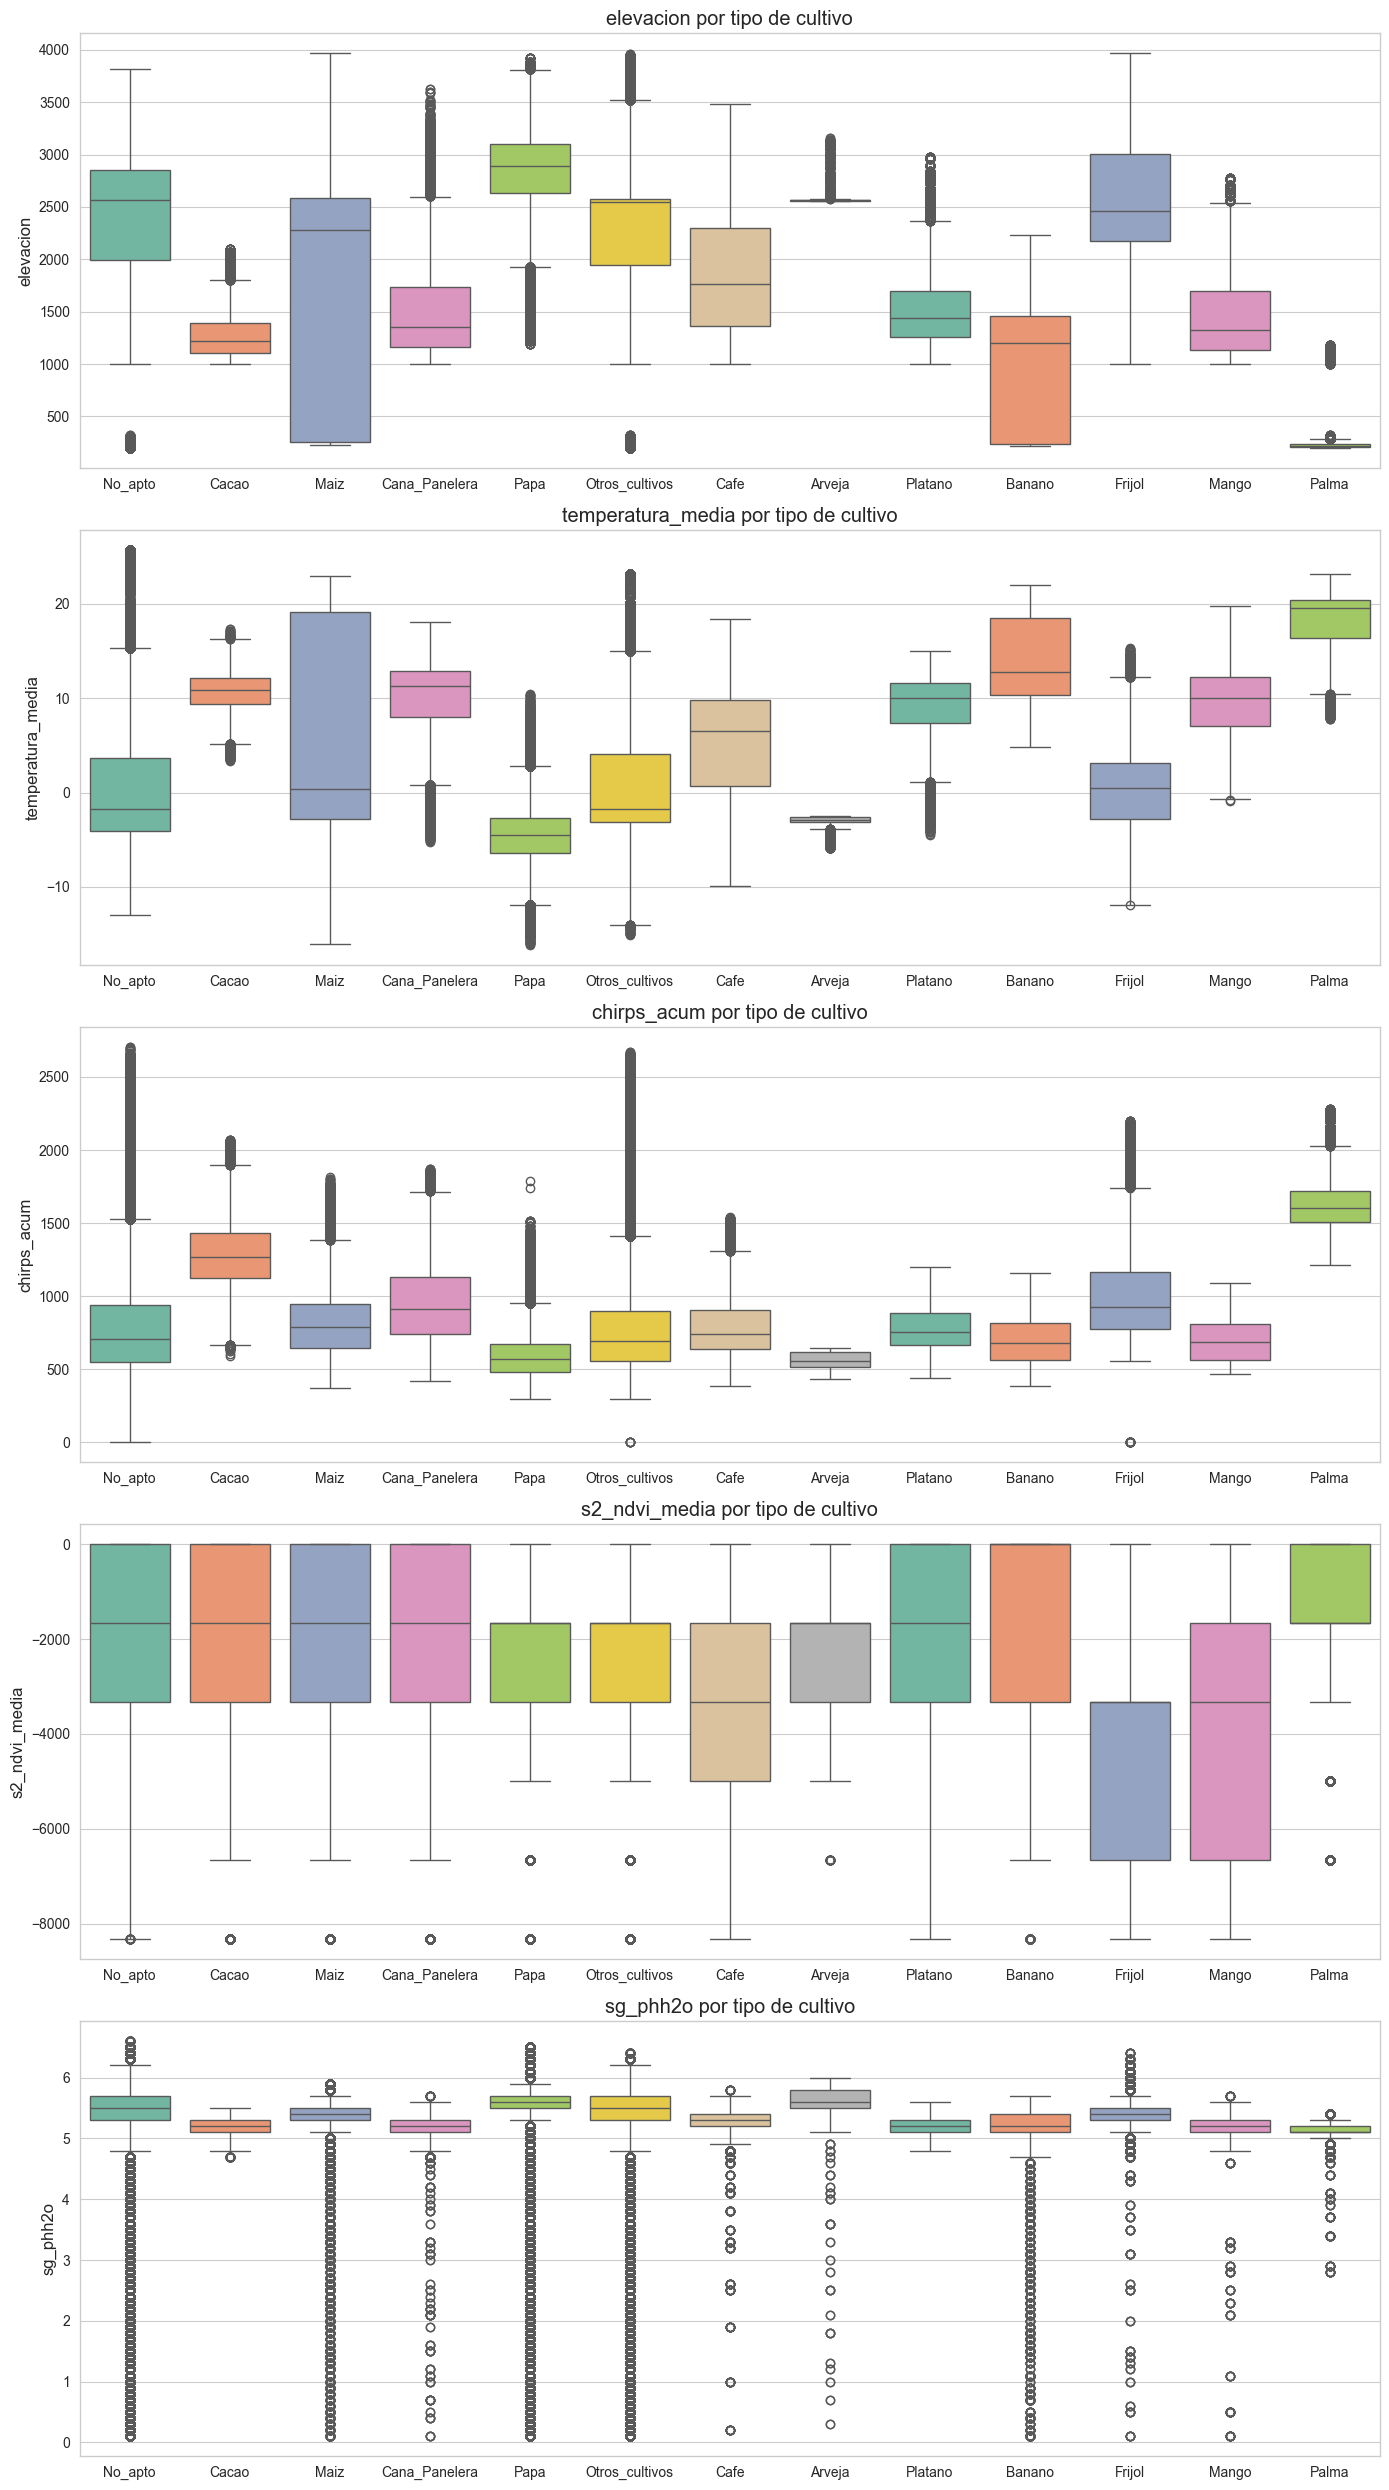

In [187]:
# Distribución de variables clave por cultivo (boxplots)
df_plot = df_raw.copy()
df_plot['cultivo_nombre'] = df_plot['cultivo_id'].map(inv_catalogo)

vars_por_cultivo = ['elevacion', 'temperatura_media', 'chirps_acum', 's2_ndvi_media', 'sg_phh2o']
vars_por_cultivo = [v for v in vars_por_cultivo if v in df_plot.columns]

fig, axes = plt.subplots(len(vars_por_cultivo), 1, figsize=(14, 5*len(vars_por_cultivo)))
for i, var in enumerate(vars_por_cultivo):
    sns.boxplot(data=df_plot, x='cultivo_nombre', y=var, ax=axes[i],
                palette='Set2', hue='cultivo_nombre', legend=False)
    axes[i].set_title(f'{var} por tipo de cultivo')
    axes[i].set_xlabel('')
plt.tight_layout()

### 2.8 Resumen de Comprensión de Datos

A partir del análisis exploratorio:

* **Dimensiones**: varios millones de registros para 14 clases de cultivo distribuidas en Cundinamarca.
* **Etiquetado jerárquico**: la columna `fuente` distingue L1 (monitoreo UPRA, alta confianza), L2 (EVA municipal, confianza moderada) y L3 (No_apto proxy, confianza baja). El modelo usará `sample_weight = confianza` para que los L1 dominen el ajuste.
* **Desbalance de clases**: Papa (por monitoreo UPRA) y No_apto (por proxy SIPRA/NDVI) concentran la mayoría de registros. Las clases minoritarias dependen de L2 EVA municipal.
* **Valores faltantes**: algunas variables satélite tienen NaNs por cobertura de nubes; se imputan por mediana.
* **Correlaciones**: Temperatura y elevación siguen muy correlacionadas (r≈-0.95). NDVI y GNDVI son casi redundantes.
* **Leakage esperado con NDVI**: `ndvi_max` se mantiene como feature aunque alimente la regla L3. El modelo reproducirá la lógica `NDVI bajo → No_apto`, que es precisamente la semántica correcta ("pixel no vegetado").
* **Particionamiento**: se usará split **por municipio** (`GroupShuffleSplit`) en lugar de estratificado aleatorio, para evitar fuga espacial entre pixeles vecinos.


---

# 3. Preparación de los Datos

### 3.1 Estrategia
- Excluir identificadores irrelevantes (`pixel_id`, `x`, `y`, `cod_mun`) y target secundarios (`cultivo`, `fuente`, `rendimiento_tha`, `confianza`).
- `confianza` se reserva como `sample_weight` en `fit()` (no entra como feature).
- `cod_mun` se reserva como `groups` para `GroupShuffleSplit` y `GroupKFold`.
- Codificación cíclica para features temporales (`semestre`).
- Separar variables por tipo (numéricas continuas, ordinales, nominales).
- Construir un preprocesador reutilizable con `Pipeline` y `ColumnTransformer`.
- **Sin SMOTE**: incompatible con `sample_weight` (los sintéticos no tienen una confianza real). Se usará `class_weight='balanced'` en LR/RF y pesos directos en XGBoost.
- Split train/valid/test **por municipio** (70/15/15 aprox), para evitar que pixeles vecinos caigan en folds distintos.


In [ ]:
# --- Definición de columnas ---

# Columnas a excluir (metadata, ids, target secundarios)
EXCLUDE_COLS = [
    'pixel_id', 'x', 'y',                 # Metadata espacial
    'cod_mun',                            # Identificador de municipio (se usa como groups)
    'cultivo',                            # Target como string (usamos cultivo_id)
    'confianza',                          # Se usa como sample_weight, NO como feature
    'fuente',                             # Etiqueta de nivel (L1/L2/L3), no feature
    'rendimiento_tha',                    # Target secundario
    'temperatura_max', 'temperatura_min', # Redundantes con temperatura_media (r>0.98)
    's2_savi_media', 's2_savi_max', 's2_savi_std',  # Redundantes con MSAVI
    'ndvi_max',                           # Duplicado exacto de s2_ndvi_max
]

# Features temporales para codificación cíclica
CYCLIC_COL = 'semestre'

# Target y columnas auxiliares
TARGET_COL = 'cultivo_id'
WEIGHT_COL = 'confianza'   # sample_weight
GROUP_COL = 'cod_mun'      # para GroupKFold / GroupShuffleSplit

print("Columnas excluidas definidas.")
print(f"Target:  {TARGET_COL}")
print(f"Peso:    {WEIGHT_COL}  (sample_weight)")
print(f"Grupos:  {GROUP_COL}   (GroupKFold)")


Columnas excluidas definidas.
Target:  cultivo_id
Peso:    confianza  (sample_weight)
Grupos:  cod_mun   (GroupKFold)


In [189]:
# --- Codificacion temporal del semestre ---
# Con solo 2 valores (A, B), la codificacion sin/cos es redundante:
#   sin(0) = 0, sin(pi) = 0 -> columna constante.
# Conservamos solo `semestre_cos` (={1: A, -1: B}) como feature binaria
# con semantica circular. Para `year_norm` usamos el rango fijo del
# proyecto (YEAR_START=2020, YEAR_END=2025) en vez de df.min()/df.max(),
# evitando leakage del test set al encoding.

YEAR_MIN = 2020   # ventana temporal del proyecto (config.YEAR_START)
YEAR_MAX = 2025   # config.YEAR_END


def encode_semestre_cyclic(df):
    """Convierte 'YYYYA'/'YYYYB' en (semestre_cos, year_norm).

    - semestre_cos: 1.0 si A, -1.0 si B (equivalente a cos(pi*k) con k in {0,1}).
    - year_norm: (year - YEAR_MIN) / (YEAR_MAX - YEAR_MIN), tendencia temporal.
    """
    df = df.copy()
    year = df['semestre'].str[:4].astype(int)
    sem = df['semestre'].str[4].map({'A': 0, 'B': 1})

    df['semestre_cos'] = np.cos(np.pi * sem).astype(np.float32)  # {1, -1}
    df['year_norm'] = ((year - YEAR_MIN) / (YEAR_MAX - YEAR_MIN)).astype(np.float32)

    df.drop(columns=['semestre'], inplace=True)
    return df


# Aplicar codificacion
df = df_raw.copy()
df = encode_semestre_cyclic(df)
print(f"Columnas despues de codificacion: {df.shape[1]}")
print(f"Nuevas columnas: semestre_cos (in {{-1, 1}}), year_norm (in [0, 1])")

df[['semestre_cos', 'year_norm']].describe()


Columnas despues de codificacion: 56
Nuevas columnas: semestre_cos (in {-1, 1}), year_norm (in [0, 1])


,semestre_cos,year_norm
count,5415961.0000,5415961.0000
mean,0.0004,0.4879
std,1.0000,0.3361
min,-1.0000,0.0000
25%,-1.0000,0.2000
50%,1.0000,0.4000
75%,1.0000,0.8000
max,1.0000,1.0000


In [190]:
# --- Separar X, y, sample_weight y groups ---

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS and c != TARGET_COL]
X = df[feature_cols]
y = df[TARGET_COL]
w = df[WEIGHT_COL].astype(float)     # sample_weight = confianza
groups = df[GROUP_COL].astype(int)   # cod_mun

print(f"Features: {X.shape[1]}")
print(f"Registros: {X.shape[0]:,}")
print(f"Municipios únicos: {groups.nunique()}")
print(f"\nDistribución de pesos (confianza):")
print(w.describe().round(3))


Features: 41
Registros: 5,415,961
Municipios únicos: 113

Distribución de pesos (confianza):
count   5415961.0000
mean          0.5730
std           0.1990
min           0.3000
25%           0.4000
50%           0.5560
75%           0.7000
max           1.0000
Name: confianza, dtype: float64


In [191]:
# --- Clasificar features por tipo ---

# Variables ordinales IGAC (ya son numericas con orden natural)
ordinal_cols = ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
ordinal_cols = [c for c in ordinal_cols if c in feature_cols]

# Variable nominal
nominal_cols = ['igac_vocacion']
nominal_cols = [c for c in nominal_cols if c in feature_cols]

# Features temporales (ya codificadas): semestre_cos binaria + tendencia year_norm
cyclic_cols = ['semestre_cos', 'year_norm']
cyclic_cols = [c for c in cyclic_cols if c in feature_cols]

# Numericas continuas (resto)
numeric_continuous = [c for c in feature_cols
                      if c not in ordinal_cols + nominal_cols + cyclic_cols]

print(f"Variables ordinales ({len(ordinal_cols)}): {ordinal_cols}")
print(f"Variables nominales ({len(nominal_cols)}): {nominal_cols}")
print(f"Variables temporales ({len(cyclic_cols)}): {cyclic_cols}")
print(f"Variables continuas ({len(numeric_continuous)}): {numeric_continuous}")


Variables ordinales (5): ['igac_ph', 'igac_fosforo', 'igac_potasio', 'igac_fertilidad', 'piso_termico']
Variables nominales (1): ['igac_vocacion']
Variables temporales (2): ['semestre_cos', 'year_norm']
Variables continuas (33): ['elevacion', 'pendiente', 'twi', 'sg_phh2o', 'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod', 'sg_clay', 'sg_sand', 'sg_silt', 'indice_fertilidad', 'aspecto_sin', 'aspecto_cos', 'temperatura_media', 'humedad_media', 'chirps_acum', 's2_ndvi_media', 's2_ndvi_max', 's2_ndvi_std', 's2_gndvi_media', 's2_gndvi_max', 's2_gndvi_std', 's2_msavi_media', 's2_msavi_max', 's2_msavi_std', 's2_bsi_media', 's2_bsi_max', 's2_bsi_std', 'amplitud_termica', 'anomalia_precip', 'ndvi_integral', 'indice_aridez']


In [192]:
# --- Partición espacial por municipio: 70% train, 15% validación, 15% prueba ---
# Usamos GroupShuffleSplit con la columna cod_mun para garantizar que los pixeles
# de un municipio dado solo aparezcan en UN fold. Esto evita la fuga espacial
# (pixeles vecinos con features muy correlacionadas en train y test).

from sklearn.model_selection import GroupShuffleSplit

# Muestreo estratificado por capacidad de cómputo (manteniendo pesos y grupos)
MAX_SAMPLES = 500_000
if len(X) > MAX_SAMPLES:
    print(f"Dataset muy grande ({len(X):,}). Tomando muestra aleatoria de {MAX_SAMPLES:,}...")
    rng = np.random.RandomState(42)
    idx = rng.choice(len(X), MAX_SAMPLES, replace=False)
    X = X.iloc[idx].reset_index(drop=True)
    y = y.iloc[idx].reset_index(drop=True)
    w = w.iloc[idx].reset_index(drop=True)
    groups = groups.iloc[idx].reset_index(drop=True)
    print(f"Muestra resultante: {X.shape[0]:,} registros, {groups.nunique()} municipios")

# Split 1: separar test (15% de municipios)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
idx_trv, idx_test = next(gss1.split(X, y, groups=groups))

X_train_valid = X.iloc[idx_trv].reset_index(drop=True)
y_train_valid = y.iloc[idx_trv].reset_index(drop=True)
w_train_valid = w.iloc[idx_trv].reset_index(drop=True)
g_train_valid = groups.iloc[idx_trv].reset_index(drop=True)

X_test = X.iloc[idx_test].reset_index(drop=True)
y_test = y.iloc[idx_test].reset_index(drop=True)
w_test = w.iloc[idx_test].reset_index(drop=True)

# Split 2: separar validación (15% de municipios del subset restante)
valid_size = 0.15 / 0.85
gss2 = GroupShuffleSplit(n_splits=1, test_size=valid_size, random_state=42)
idx_tr, idx_va = next(gss2.split(X_train_valid, y_train_valid, groups=g_train_valid))

X_train = X_train_valid.iloc[idx_tr].reset_index(drop=True)
y_train = y_train_valid.iloc[idx_tr].reset_index(drop=True)
w_train = w_train_valid.iloc[idx_tr].reset_index(drop=True)
g_train = g_train_valid.iloc[idx_tr].reset_index(drop=True)

X_valid = X_train_valid.iloc[idx_va].reset_index(drop=True)
y_valid = y_train_valid.iloc[idx_va].reset_index(drop=True)
w_valid = w_train_valid.iloc[idx_va].reset_index(drop=True)

print(f"\nParticiones por municipio:")
print(f"  Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)  |  "
      f"municipios: {g_train.nunique()}")
print(f"  Valid: {len(X_valid):,} ({len(X_valid)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Verificación: no debe haber intersección de municipios entre train/test
assert len(set(g_train) & set(groups.iloc[idx_test])) == 0, \
    "Leakage detectado: municipios en train y test"
print("\n  OK: sin intersección de municipios entre train/valid/test")

# ── Remapeo de etiquetas a espacio compacto [0..K-1] ──
# XGBoost (multi:softprob) requiere labels contiguos empezando en 0.
# Estrategia: fit del LabelEncoder SOLO sobre y_train (el modelo solo puede
# aprender lo que ve). Filtrar filas de valid/test cuya clase no este en
# train -- el modelo no podria predecirlas correctamente y su inclusion
# provoca el error "Invalid classes inferred" en XGBoost.
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le_y = LabelEncoder()
le_y.fit(y_train)

# Filtrar valid/test a clases conocidas en train (mantener X, w, g alineados)
mask_v = y_valid.isin(le_y.classes_)
mask_t = y_test.isin(le_y.classes_)
n_drop_v = int((~mask_v).sum())
n_drop_t = int((~mask_t).sum())
if n_drop_v or n_drop_t:
    print(f"  Filas descartadas por clase ausente en train: "
          f"valid={n_drop_v}, test={n_drop_t}")
    X_valid = X_valid[mask_v].reset_index(drop=True)
    y_valid = y_valid[mask_v].reset_index(drop=True)
    w_valid = w_valid[mask_v].reset_index(drop=True)
    X_test = X_test[mask_t].reset_index(drop=True)
    y_test = y_test[mask_t].reset_index(drop=True)
    w_test = w_test[mask_t].reset_index(drop=True)

# Remap al espacio [0..K-1]
y_train = pd.Series(le_y.transform(y_train), index=y_train.index)
y_valid = pd.Series(le_y.transform(y_valid), index=y_valid.index)
y_test = pd.Series(le_y.transform(y_test), index=y_test.index)

# Nombres para el reporte: le_y.classes_[k] = id_original -> inv_catalogo -> nombre
target_names_remap = [inv_catalogo.get(int(c), f'Clase_{c}') for c in le_y.classes_]

print(f"\nClases en train (modelo): {len(le_y.classes_)} de {len(catalogo)} en catalogo")
ausentes = sorted(set(catalogo.values()) - set(int(c) for c in le_y.classes_))
if ausentes:
    print(f"  Ausentes en train: "
          f"{[inv_catalogo[c] for c in ausentes]}  (ids {ausentes})")


Dataset muy grande (5,415,961). Tomando muestra aleatoria de 500,000...
Muestra resultante: 500,000 registros, 113 municipios

Particiones por municipio:
  Train: 323,250 (64.6%)  |  municipios: 79
  Valid: 45,380 (9.1%)
  Test:  131,370 (26.3%)

  OK: sin intersección de municipios entre train/valid/test
  Filas descartadas por clase ausente en train: valid=0, test=7900

Clases en train (modelo): 12 de 14 en catalogo
  Ausentes en train: ['Palma', 'Naranja']  (ids [9, 11])


In [193]:
# --- Preprocesador con ColumnTransformer ---

# Pipeline para variables continuas: imputación + escalamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables ordinales: imputación (ya son numéricas)
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Pipeline para variables nominales: imputación + one-hot
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_continuous),
    ('ord', ordinal_transformer, ordinal_cols),
    ('nom', nominal_transformer, nominal_cols),
    ('cyclic', 'passthrough', cyclic_cols)
], remainder='drop')

print("Preprocesador construido:")
print(preprocessor)

Preprocesador construido:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['elevacion', 'pendiente', 'twi', 'sg_phh2o',
                                  'sg_soc', 'sg_nitrogen', 'sg_cec', 'sg_bdod',
                                  'sg_clay', 'sg_sand', 'sg_silt',
                                  'indice_fertilidad', 'aspecto_sin',
                                  'aspecto_cos', 'temperatura_media',
                                  'humedad_media', 'chirps_acum',
                                  's2_ndvi...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['igac_ph', 'igac_fosforo', 'igac_potasio

In [194]:
# --- Aplicar preprocesamiento ---
# NO se aplica SMOTE: es incompatible con sample_weight.
# Los pesos por fila (confianza) ya se encargan del desbalance efectivo.

X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)
X_test_prep = preprocessor.transform(X_test)

print(f"Datos preprocesados:")
print(f"  X_train: {X_train_prep.shape}")
print(f"  X_valid: {X_valid_prep.shape}")
print(f"  X_test:  {X_test_prep.shape}")

# Nombres de features después del preprocesamiento
feature_names = list(numeric_continuous) + list(ordinal_cols)
if nominal_cols:
    ohe = preprocessor.named_transformers_['nom'].named_steps['encoder']
    nominal_encoded = list(ohe.get_feature_names_out(nominal_cols))
    feature_names += nominal_encoded
feature_names += cyclic_cols
print(f"\nTotal features después de preprocesamiento: {len(feature_names)}")


Datos preprocesados:
  X_train: (323250, 48)
  X_valid: (45380, 48)
  X_test:  (123470, 48)

Total features después de preprocesamiento: 48


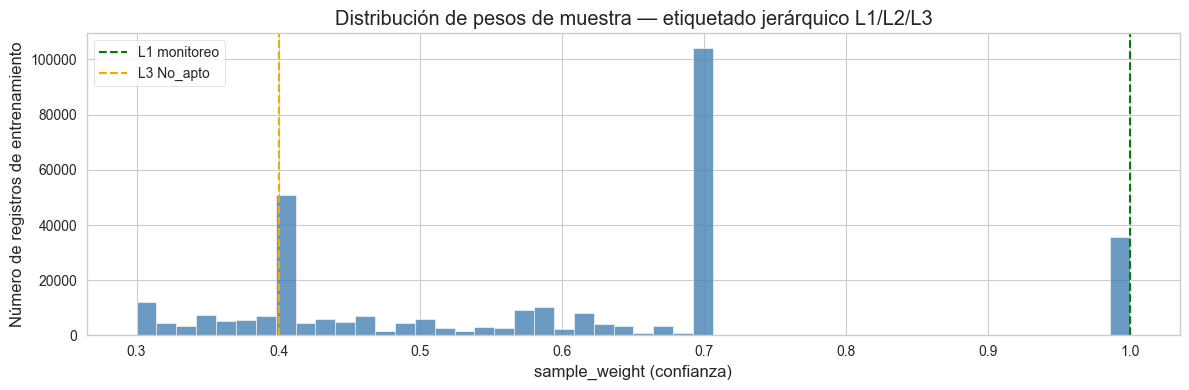

In [195]:
# --- Distribución de pesos (confianza) en entrenamiento ---
# El sample_weight es la herencia del etiquetado jerárquico:
#   conf=1.0 -> monitoreo UPRA (L1, ground truth)
#   conf=0.3-0.7 -> EVA municipal (L2, etiqueta inferida de aptitud)
#   conf=0.4 -> No_apto proxy (L3)

fig, ax = plt.subplots(figsize=(12, 4))
w_train.hist(bins=50, ax=ax, color='steelblue', alpha=0.8)
ax.set_xlabel('sample_weight (confianza)')
ax.set_ylabel('Número de registros de entrenamiento')
ax.set_title('Distribución de pesos de muestra — etiquetado jerárquico L1/L2/L3')
ax.axvline(1.0, color='green', ls='--', label='L1 monitoreo')
ax.axvline(0.4, color='orange', ls='--', label='L3 No_apto')
ax.legend()
plt.tight_layout()


In [196]:
# --- Peso efectivo = inverse-frequency x confianza ---
# El `sample_weight = confianza` refleja CALIDAD de la etiqueta (L1/L2/L3),
# no el balance de clases. Con 14 clases muy desbalanceadas (Papa y No_apto
# dominan), XGBoost necesita un factor adicional que contrarreste la frecuencia.
#
# Combinamos ambas senales:
#   eff_w = class_weight_balanced(y) * confianza
# Asi:
#   - una clase minoritaria con etiqueta L1 (papa rara alta altitud) pesa mucho,
#   - una clase mayoritaria con etiqueta L2 de baja confianza pesa poco,
#   - se reduce el colapso hacia Papa/No_apto del XGBoost.

from sklearn.utils.class_weight import compute_sample_weight

cw_train = compute_sample_weight('balanced', y_train)
cw_valid = compute_sample_weight('balanced', y_valid)
cw_test  = compute_sample_weight('balanced', y_test)

eff_w_train = cw_train * w_train.values
eff_w_valid = cw_valid * w_valid.values
eff_w_test  = cw_test  * w_test.values

print("Pesos efectivos (class_balanced x confianza):")
print(f"  train:  mean={eff_w_train.mean():.3f}  std={eff_w_train.std():.3f}  "
      f"min={eff_w_train.min():.3f}  max={eff_w_train.max():.3f}")
print(f"  valid:  mean={eff_w_valid.mean():.3f}  std={eff_w_valid.std():.3f}")
print(f"  test:   mean={eff_w_test.mean():.3f}  std={eff_w_test.std():.3f}")

# Distribucion de peso efectivo por clase en train
import pandas as pd
eff_por_clase = pd.DataFrame({'y': y_train, 'w': w_train.values, 'eff': eff_w_train})
resumen = eff_por_clase.groupby('y').agg(
    n=('eff', 'size'), w_mean=('w', 'mean'), eff_sum=('eff', 'sum')
).round(2)
resumen['clase'] = resumen.index.map(inv_catalogo)
print("\nPeso efectivo agregado por clase en train:")
print(resumen[['clase', 'n', 'w_mean', 'eff_sum']].to_string())


Pesos efectivos (class_balanced x confianza):
  train:  mean=0.469  std=4.201  min=0.044  max=327.679
  valid:  mean=0.485  std=0.903
  test:   mean=0.524  std=2.396

Peso efectivo agregado por clase en train:
            clase       n  w_mean    eff_sum
y                                           
0            Papa  194699  0.6800 18427.0700
1   Cana_Panelera    5007  0.5500 14915.4200
2            Cafe    6623  0.4900 13078.9700
3            Maiz   11265  0.4100 11079.9700
4         Platano     601  0.3400  9121.1100
5           Mango     924  0.3400  9221.1700
6          Frijol    4940  0.5500 14856.3700
7           Cacao      35  0.4300 11468.7800
8          Arveja     237  0.5900 15962.9600
9           Palma     151  0.3400  9283.3000
10         Banano   53124  0.5000 13337.9500
11        Naranja   45644  0.4000 10775.0000


### 3.2 Resultado de la Preparación

- Se excluyeron variables de metadata, identificadores y target secundarios.
- `confianza` se reserva como **`sample_weight`** (no entra como feature).
- `cod_mun` se reserva como **`groups`** para validación espacial.
- La variable `semestre` fue codificada con **codificación cíclica** (sin/cos).
- Se construyó un `ColumnTransformer` con pipelines para continuas, ordinales y nominales.
- **Sin SMOTE**: los pesos por fila ya manejan el desbalance efectivo.
- Particiones **70% train / 15% validación / 15% prueba por municipio** (`GroupShuffleSplit`).


---

# 4. Modelamiento

### 4.1 Modelos Base — Evaluación Inicial

Evaluamos modelos con sesgos y capacidades complementarias:
- **LogisticRegression**: línea base interpretable con regularización.
- **RandomForest**: ensamble de árboles robusto al ruido.
- **XGBoost**: gradient boosting de alto desempeño (modelo principal).

Todos los modelos se entrenan con **`sample_weight = confianza`** para que los pixeles L1 (monitoreo UPRA) dominen el ajuste.


In [197]:
# --- Funcion de evaluacion de modelos ---

def evaluate_model(name, model, X_tr, y_tr, X_va, y_va,
                   w_tr=None, w_va=None):
    """Entrena con sample_weight (si se provee) y reporta metricas ponderadas
    y crudas en validacion.

    Se espera que w_tr sea el PESO EFECTIVO (class_balanced x confianza).
    Para w_va pasa el mismo peso efectivo; ademas se calculan metricas no
    ponderadas para exponer el desempenyo en clases minoritarias."""
    fit_kwargs = {}
    if w_tr is not None:
        fit_kwargs['sample_weight'] = w_tr
    model.fit(X_tr, y_tr, **fit_kwargs)

    preds = model.predict(X_va)
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_va)
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_va)
    else:
        proba = None

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_va, preds, sample_weight=w_va),
        'f1_macro': f1_score(y_va, preds, average='macro',
                             sample_weight=w_va, zero_division=0),
        'f1_macro_crudo': f1_score(y_va, preds, average='macro', zero_division=0),
        'precision_macro': precision_score(y_va, preds, average='macro',
                                           sample_weight=w_va, zero_division=0),
        'recall_macro': recall_score(y_va, preds, average='macro',
                                     sample_weight=w_va, zero_division=0),
        'roc_auc_ovr': np.nan,
    }

    # ROC-AUC OvR macro. `model.classes_` da el orden exacto de columnas de proba;
    # label_binarize contra esas clases funciona aunque y_va no contenga todas.
    if proba is not None and hasattr(model, 'classes_'):
        try:
            model_classes = model.classes_
            y_va_bin = label_binarize(y_va, classes=model_classes)
            if y_va_bin.shape[1] == proba.shape[1] and y_va_bin.shape[1] > 1:
                metrics['roc_auc_ovr'] = roc_auc_score(
                    y_va_bin, proba, multi_class='ovr', average='macro',
                    sample_weight=w_va
                )
        except (ValueError, IndexError):
            pass

    return metrics, model, preds, proba

print("Funcion de evaluacion definida (soporta eff_w; reporta F1 ponderado y crudo).")


Funcion de evaluacion definida (soporta eff_w; reporta F1 ponderado y crudo).


In [198]:
# --- Entrenar modelos base con eff_w (class_balanced x confianza) ---
# En XGBoost no se puede pasar class_weight directo; aqui eff_w hace el trabajo.
# En LR/RF mantenemos class_weight='balanced' para que sklearn lo multiplique
# internamente con el eff_w (doble refuerzo inofensivo, el efecto dominante
# sigue siendo la ponderacion inversa-frecuencia).

n_classes = len(np.unique(y_train))

models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        solver='lbfgs', random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=15,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=n_classes,
        eval_metric='mlogloss', random_state=42,
        n_jobs=-1, tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Entrenando {name}...")
    metrics, trained, preds, proba = evaluate_model(
        name, model, X_train_prep, y_train, X_valid_prep, y_valid,
        w_tr=eff_w_train, w_va=eff_w_valid
    )
    results.append(metrics)
    trained_models[name] = trained
    print(f"  F1_macro={metrics['f1_macro']:.4f}  "
          f"(crudo={metrics['f1_macro_crudo']:.4f})  "
          f"Acc={metrics['accuracy']:.4f}  ROC-AUC={metrics['roc_auc_ovr']:.4f}")

print("\nModelos base entrenados.")


Entrenando LogisticRegression...


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  F1_macro=0.1807  (crudo=0.1606)  Acc=0.3294  ROC-AUC=nan
Entrenando RandomForest...


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


  F1_macro=0.1719  (crudo=0.1679)  Acc=0.3412  ROC-AUC=nan
Entrenando XGBoost...


d:\trabajo\agroplus\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [06:14:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  F1_macro=0.1676  (crudo=0.1749)  Acc=0.3677  ROC-AUC=nan

Modelos base entrenados.


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [199]:
# --- Comparación de modelos base ---

metrics_df = pd.DataFrame(results).set_index('model').sort_values('f1_macro', ascending=False)
print("Comparación de modelos base (ordenados por F1 macro):")
metrics_df

Comparación de modelos base (ordenados por F1 macro):


,accuracy,f1_macro,f1_macro_crudo,precision_macro,recall_macro,roc_auc_ovr
model,,,,,,
LogisticRegression,0.3294,0.1807,0.1606,0.2865,0.1591,NaN
RandomForest,0.3412,0.1719,0.1679,0.2719,0.1646,NaN
XGBoost,0.3677,0.1676,0.1749,0.2238,0.1763,NaN


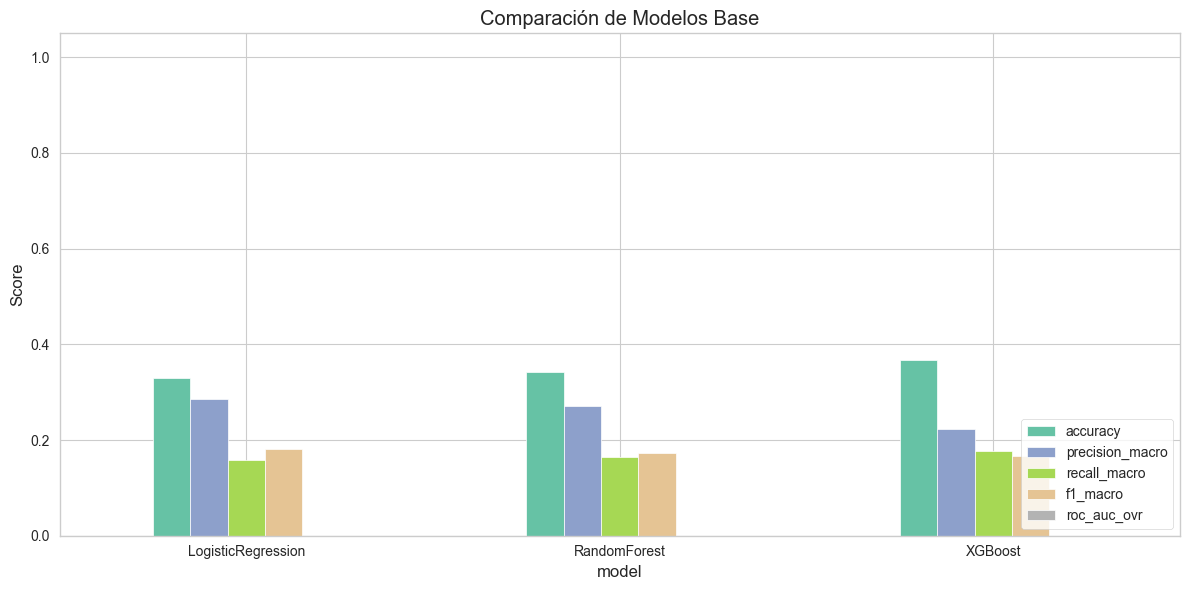

In [200]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df[['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']].plot(
    kind='bar', ax=ax, colormap='Set2'
)
ax.set_title('Comparación de Modelos Base')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()

### 4.2 Regularización didáctica — LogisticRegression con L1 y L2

Evaluación compacta del efecto de L1 (Lasso, inducción de selección de variables) y L2 (Ridge, control de colinealidad) sobre LR. XGBoost ya incorpora su propia regularización (`reg_alpha`, `reg_lambda`), que se tunea con Optuna más adelante, por lo que este bloque queda como referencia comparativa con 3 valores de C.


In [201]:
# --- Regularizacion L1 y L2 (version reducida: 3 valores de C) ---

C_values = [0.01, 1.0, 100.0]   # fuerte / media / debil
reg_results = []

for penalty in ['l1', 'l2']:
    for C in C_values:
        solver = 'saga' if penalty == 'l1' else 'lbfgs'
        lr = LogisticRegression(
            penalty=penalty, C=C, solver=solver,
            max_iter=2000, class_weight='balanced',
            random_state=42
        )
        lr.fit(X_train_prep, y_train, sample_weight=eff_w_train)
        preds = lr.predict(X_valid_prep)
        f1 = f1_score(y_valid, preds, average='macro',
                      sample_weight=eff_w_valid, zero_division=0)
        n_nonzero = np.mean([np.sum(c != 0) for c in lr.coef_])

        reg_results.append({
            'penalty': penalty.upper(), 'C': C, 'f1_macro': f1,
            'n_nonzero_coefs': n_nonzero
        })
        print(f"  {penalty.upper()} C={C:>6} -> F1={f1:.4f} | "
              f"coefs no-zero={n_nonzero:.0f}/{X_train_prep.shape[1]}")

reg_df = pd.DataFrame(reg_results)
reg_df


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  L1 C=  0.01 -> F1=0.1547 | coefs no-zero=44/48


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


  L1 C=   1.0 -> F1=0.1758 | coefs no-zero=47/48


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  L1 C= 100.0 -> F1=0.1797 | coefs no-zero=47/48
  L2 C=  0.01 -> F1=0.1655 | coefs no-zero=48/48
  L2 C=   1.0 -> F1=0.1807 | coefs no-zero=48/48
  L2 C= 100.0 -> F1=0.1804 | coefs no-zero=48/48


,penalty,C,f1_macro,n_nonzero_coefs
0,L1,0.0100,0.1547,43.7500
1,L1,1.0000,0.1758,46.5833
2,L1,100.0000,0.1797,47.4167
3,L2,0.0100,0.1655,48.0000
4,L2,1.0000,0.1807,48.0000
5,L2,100.0000,0.1804,48.0000


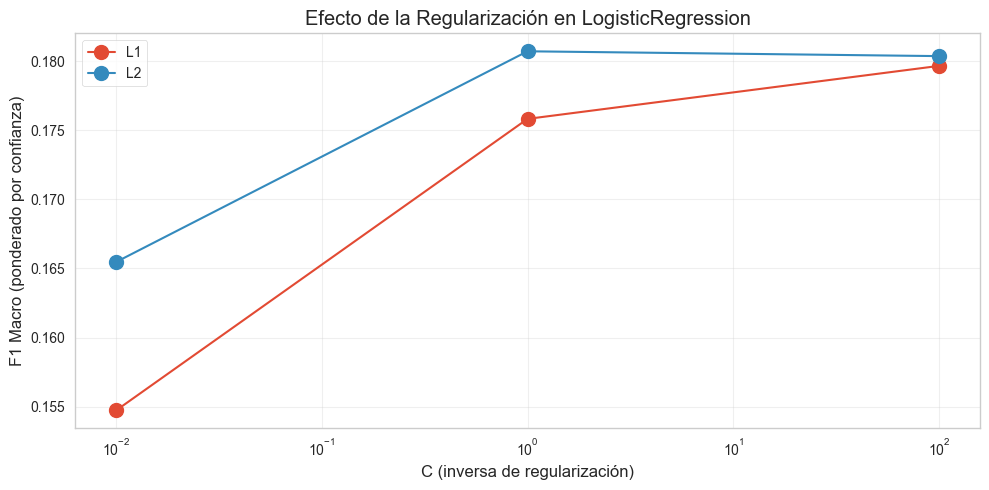

In [202]:
# Visualización de regularización
fig, ax = plt.subplots(figsize=(10, 5))
for penalty in ['L1', 'L2']:
    subset = reg_df[reg_df['penalty'] == penalty]
    ax.plot(subset['C'], subset['f1_macro'], '-o', label=f'{penalty}', markersize=10)
ax.set_xscale('log')
ax.set_xlabel('C (inversa de regularización)')
ax.set_ylabel('F1 Macro (ponderado por confianza)')
ax.set_title('Efecto de la Regularización en LogisticRegression')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


### 4.3 XGBoost — Modelo Principal

XGBoost es nuestro modelo principal por su capacidad para manejar:
- Relaciones no lineales
- Variables de diferentes escalas
- Clases desbalanceadas
- Alta dimensionalidad

In [203]:
# --- XGBoost con early stopping (sample_weight = effective weights) ---

eval_set = [
    (X_train_prep, y_train),
    (X_valid_prep, y_valid)
]

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
    tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
)

xgb_model.fit(
    X_train_prep, y_train,
    sample_weight=eff_w_train,
    sample_weight_eval_set=[eff_w_train, eff_w_valid],
    eval_set=eval_set,
    verbose=50
)

print(f"\nMejor iteracion: {xgb_model.best_iteration}")
print(f"Mejor score: {xgb_model.best_score:.4f}")


[0]	validation_0-mlogloss:2.25399	validation_1-mlogloss:2.43429
[50]	validation_0-mlogloss:0.42678	validation_1-mlogloss:2.20975
[73]	validation_0-mlogloss:0.29189	validation_1-mlogloss:2.38449

Mejor iteracion: 23
Mejor score: 2.1035


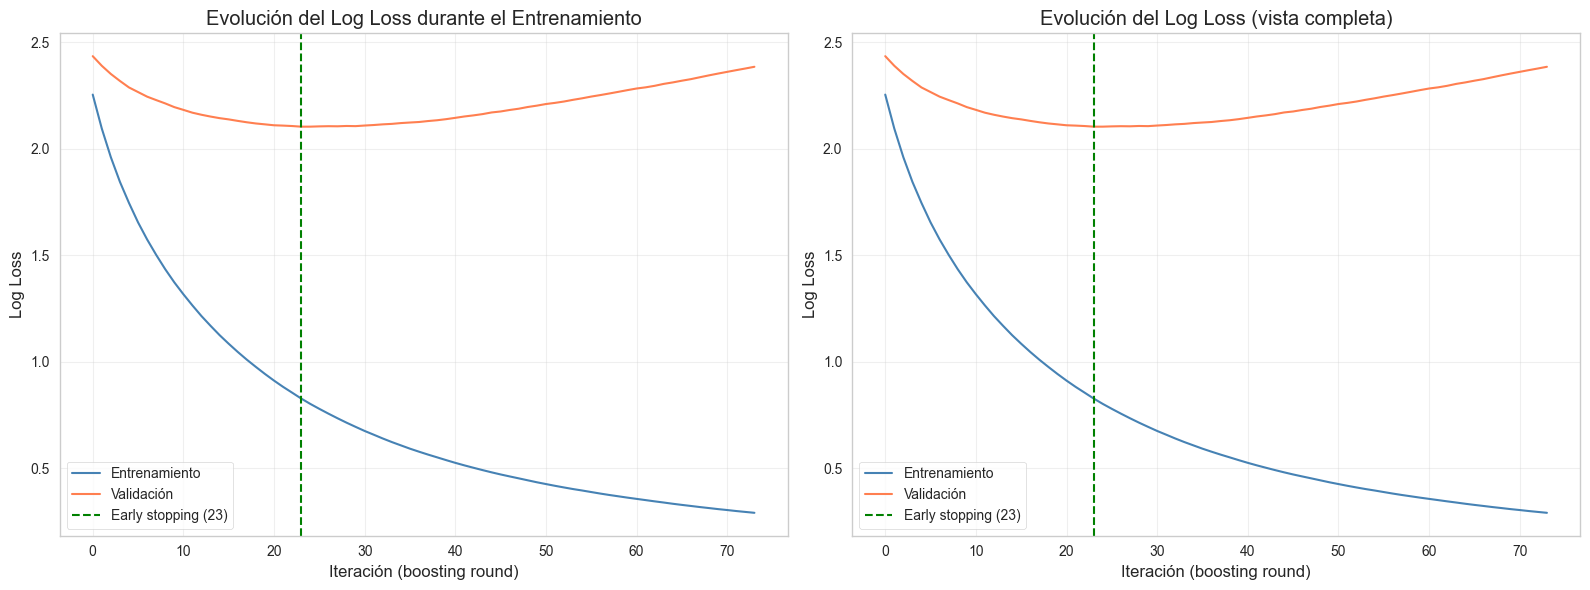

In [204]:
# --- Visualización del Proceso de Entrenamiento ---
#
# Graficamos la evolución de la función de pérdida (loss) y la precisión (accuracy)
# durante el entrenamiento. Esto permite:
# - Identificar si hay **overfitting**: cuando la pérdida de entrenamiento disminuye
#   pero la de validación aumenta
# - Verificar que el modelo **converge**: las curvas se estabilizan
# - Confirmar que el **early stopping** funcionó correctamente

results_xgb = xgb_model.evals_result()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Curva de pérdida (log loss)
epochs = len(results_xgb['validation_0']['mlogloss'])
x_axis = range(0, epochs)

ax1.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
ax1.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
ax1.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
ax1.set_xlabel('Iteración (boosting round)')
ax1.set_ylabel('Log Loss')
ax1.set_title('Evolución del Log Loss durante el Entrenamiento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calcular accuracy por iteración a partir de las predicciones
# Nota: XGBoost guarda merror para multi-class
if 'merror' in results_xgb['validation_0']:
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_0']['merror']], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, [1-e for e in results_xgb['validation_1']['merror']], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Evolución del Accuracy durante el Entrenamiento')
else:
    ax2.plot(x_axis, results_xgb['validation_0']['mlogloss'], label='Entrenamiento', color='steelblue')
    ax2.plot(x_axis, results_xgb['validation_1']['mlogloss'], label='Validación', color='coral')
    ax2.axvline(x=xgb_model.best_iteration, color='green', linestyle='--', label=f'Early stopping ({xgb_model.best_iteration})')
    ax2.set_ylabel('Log Loss')
    ax2.set_title('Evolución del Log Loss (vista completa)')

ax2.set_xlabel('Iteración (boosting round)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

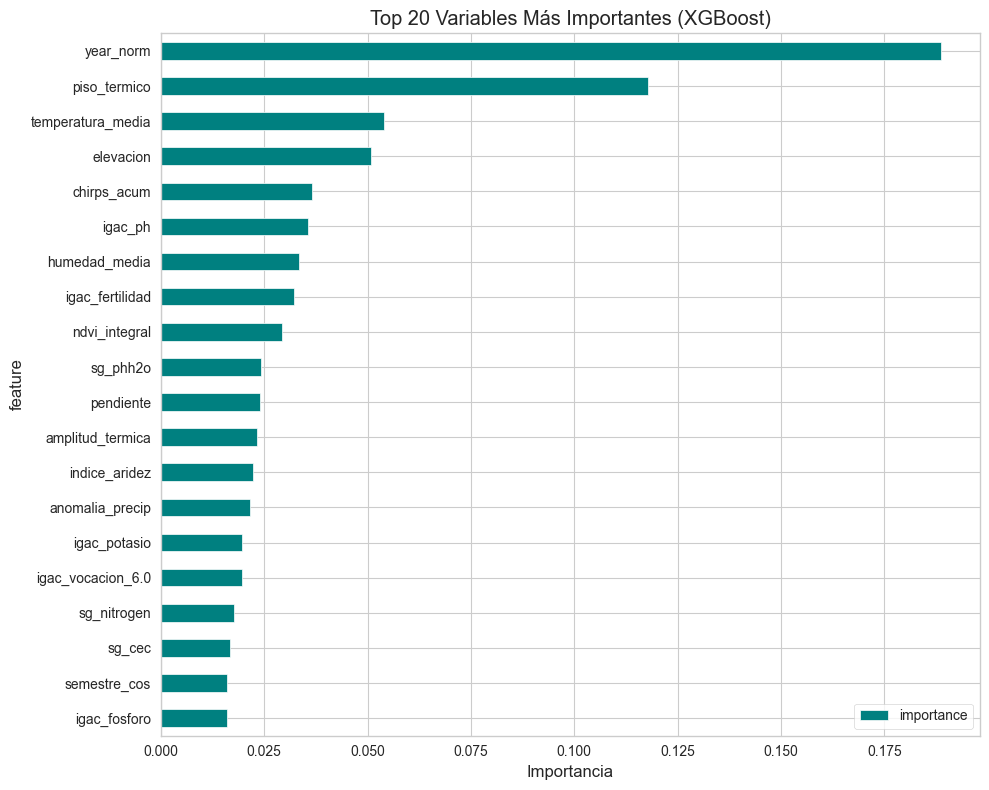

In [205]:
# --- Importancia de variables (XGBoost) ---

importance = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_names[:len(importance)],
    'importance': importance
}).sort_values('importance', ascending=False)

# Top 20 features
top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(top_n).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax, color='teal'
)
ax.set_title(f'Top {top_n} Variables Más Importantes (XGBoost)')
ax.set_xlabel('Importancia')
plt.tight_layout()

### 4.4 Optimización Bayesiana con Optuna

Optuna realiza una búsqueda inteligente del espacio de hiperparámetros usando optimización bayesiana (TPE), mucho más eficiente que Grid Search.

In [206]:
# --- Optimizacion bayesiana con Optuna (eff_w = class_balanced x confianza) ---

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1,
        'tree_method': XGB_TREE_METHOD, 'device': XGB_DEVICE
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train_prep, y_train,
        sample_weight=eff_w_train,
        eval_set=[(X_valid_prep, y_valid)],
        sample_weight_eval_set=[eff_w_valid],
        verbose=False
    )
    preds = model.predict(X_valid_prep)
    f1 = f1_score(y_valid, preds, average='macro',
                  sample_weight=eff_w_valid, zero_division=0)
    return f1

N_TRIALS = 30
study = optuna.create_study(direction='maximize', study_name='xgb_optuna')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMejor F1 macro (ponderado): {study.best_value:.4f}")
print(f"Mejores parametros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Best trial: 10. Best value: 0.183216: 100%|██████████| 30/30 [08:05<00:00, 16.20s/it]


Mejor F1 macro (ponderado): 0.1832
Mejores parametros:
  n_estimators: 116
  max_depth: 3
  learning_rate: 0.02260978459505422
  subsample: 0.8414769945263466
  colsample_bytree: 0.508749800487617
  min_child_weight: 2
  gamma: 2.8338176191185926
  reg_alpha: 0.05045131136969416
  reg_lambda: 2.716518846770167


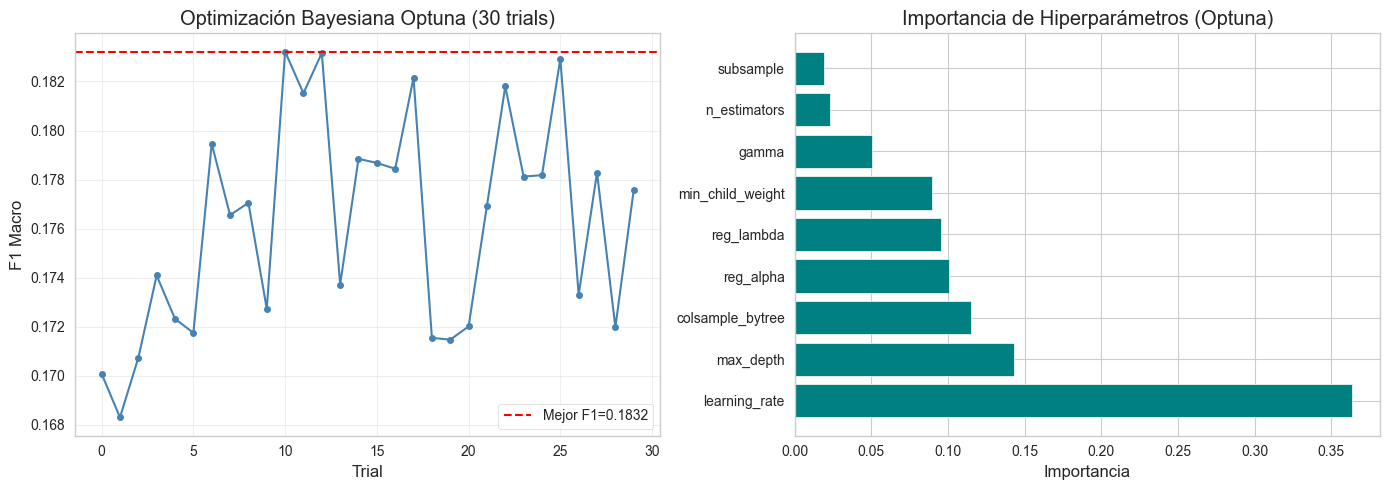

In [207]:
# Visualización de la optimización Optuna
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Historial de trials
trials_df = study.trials_dataframe()
ax1.plot(trials_df['number'], trials_df['value'], '-o', markersize=4, color='steelblue')
ax1.axhline(y=study.best_value, color='red', linestyle='--', label=f'Mejor F1={study.best_value:.4f}')
ax1.set_xlabel('Trial')
ax1.set_ylabel('F1 Macro')
ax1.set_title(f'Optimización Bayesiana Optuna ({N_TRIALS} trials)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Importancia de hiperparámetros
try:
    import optuna.visualization.matplotlib as vis
    param_imp = optuna.importance.get_param_importances(study)
    params = list(param_imp.keys())
    importances = list(param_imp.values())
    ax2.barh(params, importances, color='teal')
    ax2.set_xlabel('Importancia')
    ax2.set_title('Importancia de Hiperparámetros (Optuna)')
except Exception as e:
    ax2.text(0.5, 0.5, f'No disponible: {str(e)}', transform=ax2.transAxes, ha='center')

plt.tight_layout()

### 4.5 GridSearchCV con GroupKFold espacial

#### ¿Por qué GroupKFold en lugar de StratifiedKFold?

El dataset tiene **autocorrelación espacial**: pixeles vecinos de un mismo municipio comparten suelo, clima y topografía casi idénticos. Si un partición estratificada aleatoria pone algunos pixeles de un municipio en train y otros en test, el modelo "memoriza" el municipio y no el patrón biofísico — el score de CV se infla artificialmente.

**GroupKFold** garantiza que todos los pixeles de un municipio estén en un solo fold. Cada fold entrena con ~105 municipios y evalúa en ~12, simulando predicción en zonas realmente no vistas.

| Concepto | Descripción |
|----------|-------------|
| **GroupKFold** | Divide los datos en K pliegues respetando la estructura de grupos (aquí `cod_mun`) |
| **Sin estratificación** | Sklearn no provee `StratifiedGroupKFold` robusto con pesos; asumimos que la distribución de clases por municipio es suficientemente variada |
| **Detección de overfitting** | Si la diferencia entre score train y score CV es grande (>15%) en GroupKFold, el modelo depende de identidad espacial |
| **Generalización** | El score promedio estima el rendimiento en municipios no vistos, que es el caso real de uso |

GridSearchCV combina esta validación cruzada con una **búsqueda exhaustiva en grilla** de hiperparámetros.


In [208]:
# --- GridSearchCV con GroupKFold (10 folds espaciales) ---

from sklearn.model_selection import GroupKFold

best_params = study.best_params

param_grid = {
    'n_estimators': [best_params.get('n_estimators', 300)],
    'max_depth': [
        max(3, best_params.get('max_depth', 6) - 2),
        best_params.get('max_depth', 6),
        best_params.get('max_depth', 6) + 2
    ],
    'learning_rate': [
        best_params.get('learning_rate', 0.1) * 0.5,
        best_params.get('learning_rate', 0.1),
        best_params.get('learning_rate', 0.1) * 1.5
    ],
    'subsample': [0.7, 0.85, 1.0],
}

xgb_grid = XGBClassifier(
    objective='multi:softprob', num_class=n_classes,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, tree_method=XGB_TREE_METHOD, device=XGB_DEVICE
)

cv_group = GroupKFold(n_splits=10)

grid_search = GridSearchCV(
    xgb_grid, param_grid,
    cv=cv_group.split(X_train_prep, y_train, groups=g_train),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_prep, y_train, sample_weight=eff_w_train)

print(f"\nMejores parametros GridSearchCV (espacial):")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor F1 macro (CV espacial): {grid_search.best_score_:.4f}")


Fitting 10 folds for each of 27 candidates, totalling 270 fits


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
108 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\trabajo\agroplus\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "d:\trabajo\agroplus\.venv\Lib\site-packages\xgboost\sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique v


Mejores parametros GridSearchCV (espacial):
  learning_rate: 0.01130489229752711
  max_depth: 3
  n_estimators: 116
  subsample: 0.7

Mejor F1 macro (CV espacial): nan


In [209]:
# Resultados del GridSearchCV
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score')
print("Top 10 combinaciones de GridSearchCV:")
cv_results_sorted.head(10)

Top 10 combinaciones de GridSearchCV:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
1,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
2,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
3,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
4,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
5,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
6,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
7,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
8,"{'learning_rate': 0.01130489229752711, 'max_de...",NaN,NaN,1
9,"{'learning_rate': 0.02260978459505422, 'max_de...",NaN,NaN,1


### 4.6 Modelo Final — Entrenamiento con mejores hiperparámetros

Entrenamos el modelo final con los mejores hiperparámetros encontrados y todo el conjunto de entrenamiento+validación.

In [210]:
# --- Modelo final: XGBoost optimizado, entrenado sobre train + valid ---

X_train_final = np.vstack([X_train_prep, X_valid_prep])
y_train_final = np.concatenate([y_train, y_valid])
eff_w_train_final = np.concatenate([eff_w_train, eff_w_valid])

final_params = grid_search.best_params_.copy()
final_params.update({
    'objective': 'multi:softprob',
    'num_class': n_classes,
    'eval_metric': 'mlogloss',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': XGB_TREE_METHOD, 'device': XGB_DEVICE
})

final_model = XGBClassifier(**final_params)
final_model.fit(
    X_train_final, y_train_final,
    sample_weight=eff_w_train_final,
    eval_set=[(X_train_final, y_train_final), (X_test_prep, y_test)],
    sample_weight_eval_set=[eff_w_train_final, eff_w_test],
    verbose=False
)

test_preds = final_model.predict(X_test_prep)
test_proba = final_model.predict_proba(X_test_prep)

print(f"Modelo final entrenado con {X_train_final.shape[0]:,} registros.")
print(f"Predicciones generadas para {X_test_prep.shape[0]:,} registros de prueba.")


Modelo final entrenado con 368,630 registros.
Predicciones generadas para 123,470 registros de prueba.


---

# 5. Evaluación del Modelo

### 5.1 Métricas de Evaluación

Evaluamos el modelo final con las siguientes métricas:
- **Accuracy**: porcentaje total de predicciones correctas.
- **Precision** (macro): de los predichos como clase X, cuántos realmente lo eran.
- **Recall** (macro): de los que realmente son clase X, cuántos detectó el modelo.
- **F1** (macro): media armónica de precision y recall.
- **ROC-AUC** (one-vs-rest): capacidad de discriminación del modelo.

In [211]:
# --- Metricas globales en test: DUAL REPORT ---
# Dos vistas:
#  (1) Ponderado por confianza (w_test): pixeles L1 pesan mas que L2/L3.
#  (2) Crudo (sin pesos): expone desempenyo en clases minoritarias.

# `classes` son los IDs remapeados [0..K-1] (espacio del modelo).
# Para el reporte necesitamos los nombres via le_y.classes_ -> inv_catalogo.
classes = np.arange(len(le_y.classes_))


def _metricas(y_true, y_pred, proba, sw=None, etiqueta=''):
    m = {
        f'Accuracy ({etiqueta})':
            accuracy_score(y_true, y_pred, sample_weight=sw),
        f'Precision macro ({etiqueta})':
            precision_score(y_true, y_pred, average='macro',
                            sample_weight=sw, zero_division=0),
        f'Recall macro ({etiqueta})':
            recall_score(y_true, y_pred, average='macro',
                         sample_weight=sw, zero_division=0),
        f'F1 macro ({etiqueta})':
            f1_score(y_true, y_pred, average='macro',
                     sample_weight=sw, zero_division=0),
    }
    y_bin = label_binarize(y_true, classes=classes)
    if proba.shape[1] == len(classes):
        try:
            m[f'ROC-AUC OvR macro ({etiqueta})'] = roc_auc_score(
                y_bin, proba, multi_class='ovr', average='macro',
                sample_weight=sw
            )
        except ValueError:
            pass
    return m


test_metrics_pond = _metricas(y_test, test_preds, test_proba,
                              sw=w_test.values, etiqueta='ponderado confianza')
test_metrics_crudo = _metricas(y_test, test_preds, test_proba,
                               sw=None, etiqueta='crudo')

print("=" * 60)
print("METRICAS DEL MODELO FINAL EN TEST (dual: ponderado + crudo)")
print("=" * 60)
for k, v in test_metrics_pond.items():
    print(f"  {k}: {v:.4f}")
print("-" * 60)
for k, v in test_metrics_crudo.items():
    print(f"  {k}: {v:.4f}")

# Desglose por nivel (inferido de confianza raw)
w_arr = w_test.values
mask_L1 = w_arr >= 0.95
mask_L3 = (w_arr > 0.35) & (w_arr < 0.45)
mask_L2 = ~(mask_L1 | mask_L3)
print("\nDesglose por nivel (F1 macro crudo):")
for name, mask in [('L1 monitoreo', mask_L1), ('L2 EVA', mask_L2), ('L3 No_apto', mask_L3)]:
    if mask.sum() > 0:
        f1_sub = f1_score(y_test[mask], test_preds[mask], average='macro', zero_division=0)
        acc_sub = accuracy_score(y_test[mask], test_preds[mask])
        print(f"  {name:<15} n={mask.sum():>7,}  F1_macro={f1_sub:.4f}  Acc={acc_sub:.4f}")


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


METRICAS DEL MODELO FINAL EN TEST (dual: ponderado + crudo)
  Accuracy (ponderado confianza): 0.4587
  Precision macro (ponderado confianza): 0.1580
  Recall macro (ponderado confianza): 0.2101
  F1 macro (ponderado confianza): 0.1282
  ROC-AUC OvR macro (ponderado confianza): nan
------------------------------------------------------------
  Accuracy (crudo): 0.4082
  Precision macro (crudo): 0.1475
  Recall macro (crudo): 0.2147
  F1 macro (crudo): 0.1209
  ROC-AUC OvR macro (crudo): nan

Desglose por nivel (F1 macro crudo):
  L1 monitoreo    n= 10,695  F1_macro=0.0939  Acc=0.4262
  L2 EVA          n= 34,905  F1_macro=0.2095  Acc=0.7151
  L3 No_apto      n= 77,870  F1_macro=0.0510  Acc=0.2682


d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [212]:
# --- Reporte de clasificacion detallado por clase (dual) ---

# target_names_remap fue definido al final del split; alinea IDs remapeados
# a nombres del catalogo via le_y.classes_.

print("Reporte PONDERADO por confianza (mira pixeles L1 mas de cerca):")
print(classification_report(y_test, test_preds, target_names=target_names_remap,
                            sample_weight=w_test.values, zero_division=0))

print("\n" + "=" * 70)
print("Reporte CRUDO (todas las clases pesan igual por observacion):")
print(classification_report(y_test, test_preds, target_names=target_names_remap,
                            zero_division=0))


Reporte PONDERADO por confianza (mira pixeles L1 mas de cerca):
                precision    recall  f1-score   support

          Papa       0.66      0.87      0.75 24229.488377273083
 Cana_Panelera       0.06      0.77      0.12 200.8999965786934
          Cafe       0.01      0.08      0.01 333.592675358057
          Maiz       0.01      0.12      0.01 218.96850380301476
       Platano       0.00      0.00      0.00       0.0
         Mango       0.11      0.33      0.16 94.07259833812714
        Frijol       0.01      0.06      0.02 1297.5520188510418
         Cacao       0.00      0.00      0.00       0.0
        Arveja       0.00      0.00      0.00       0.0
        Banano       0.00      0.00      0.00       0.0
Otros_cultivos       0.04      0.02      0.03 9011.925065845251
       No_apto       1.00      0.28      0.44 29249.200435847044

      accuracy                           0.46 64635.69967189431
     macro avg       0.16      0.21      0.13 64635.69967189431
  weighted 

### 5.2 Matriz de Confusión

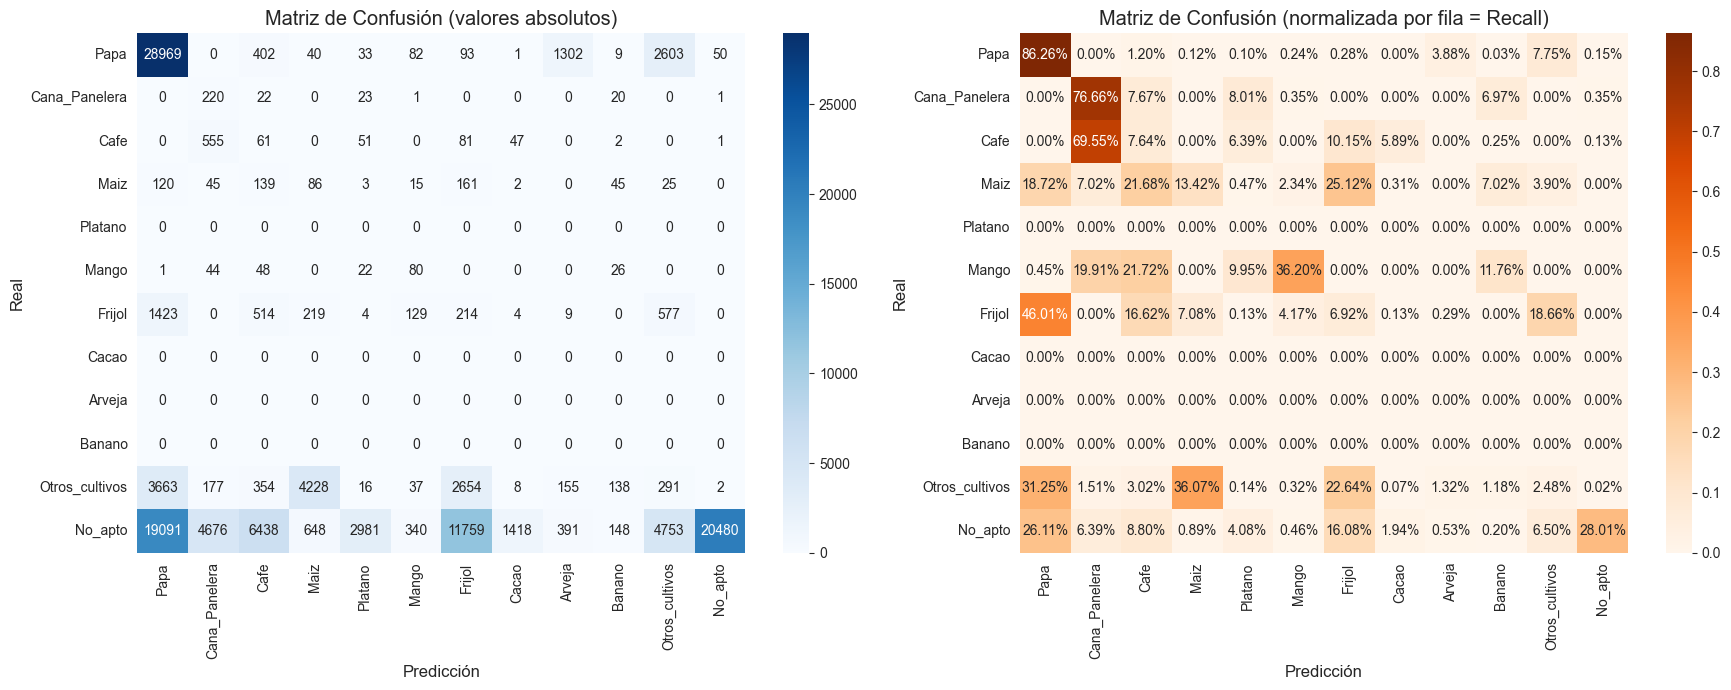

In [216]:
# --- Matriz de confusión ---
target_names = target_names_remap  # definido en celda de split

cm = confusion_matrix(y_test, test_preds)

# Normalizada por fila (recall por clase)
cm_norm = confusion_matrix(y_test, test_preds, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Matriz absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=target_names, yticklabels=target_names)
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Real')
ax1.set_title('Matriz de Confusión (valores absolutos)')

# Matriz normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=ax2,
            xticklabels=target_names, yticklabels=target_names)
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Real')
ax2.set_title('Matriz de Confusión (normalizada por fila = Recall)')

plt.tight_layout()

### 5.3 Curvas ROC-AUC (One-vs-Rest)

d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\trabajo\agroplus\.venv\Lib\site-packa

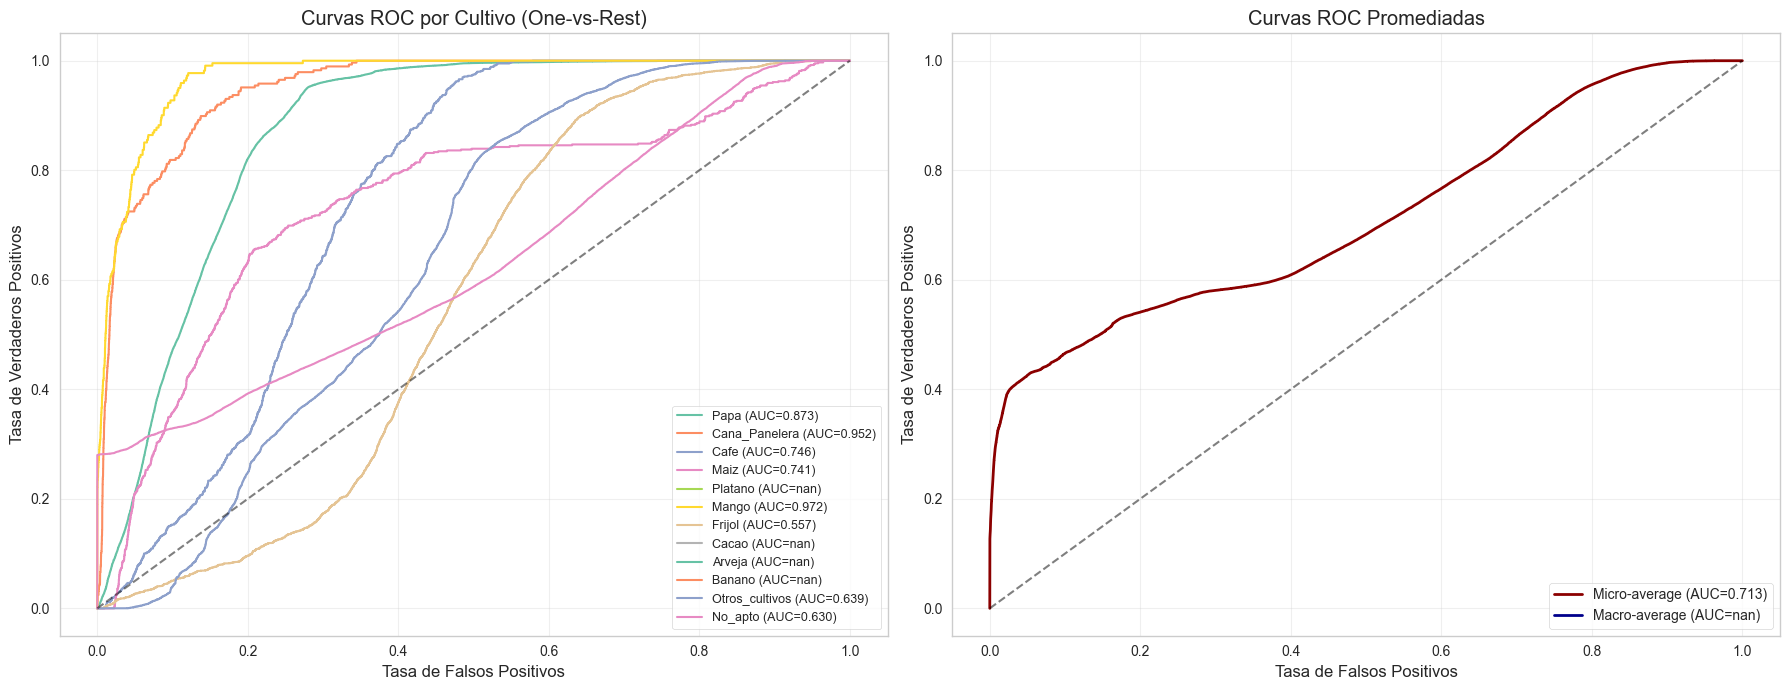

In [217]:
# --- Curvas ROC por clase (One-vs-Rest) ---
target_names = target_names_remap
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Curvas ROC individuales
colors = sns.color_palette('Set2', len(classes))
for i, (cls, name) in enumerate(zip(classes, target_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colors[i],
                 label=f'{name} (AUC={roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC por Cultivo (One-vs-Rest)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Micro-promedio ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), test_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
axes[1].plot(fpr_micro, tpr_micro, color='darkred', lw=2,
             label=f'Micro-average (AUC={roc_auc_micro:.3f})')

# Macro-promedio ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], test_proba[:, i])[0] for i in range(len(classes))]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(len(classes)):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
mean_tpr /= len(classes)
roc_auc_macro = auc(all_fpr, mean_tpr)
axes[1].plot(all_fpr, mean_tpr, color='darkblue', lw=2,
             label=f'Macro-average (AUC={roc_auc_macro:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curvas ROC Promediadas')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

### 5.4 Análisis de Residuos

El análisis de residuos en clasificación examina los errores del modelo para entender:
- Qué clases se confunden más entre sí
- Distribución de probabilidades predichas
- Calibración del modelo

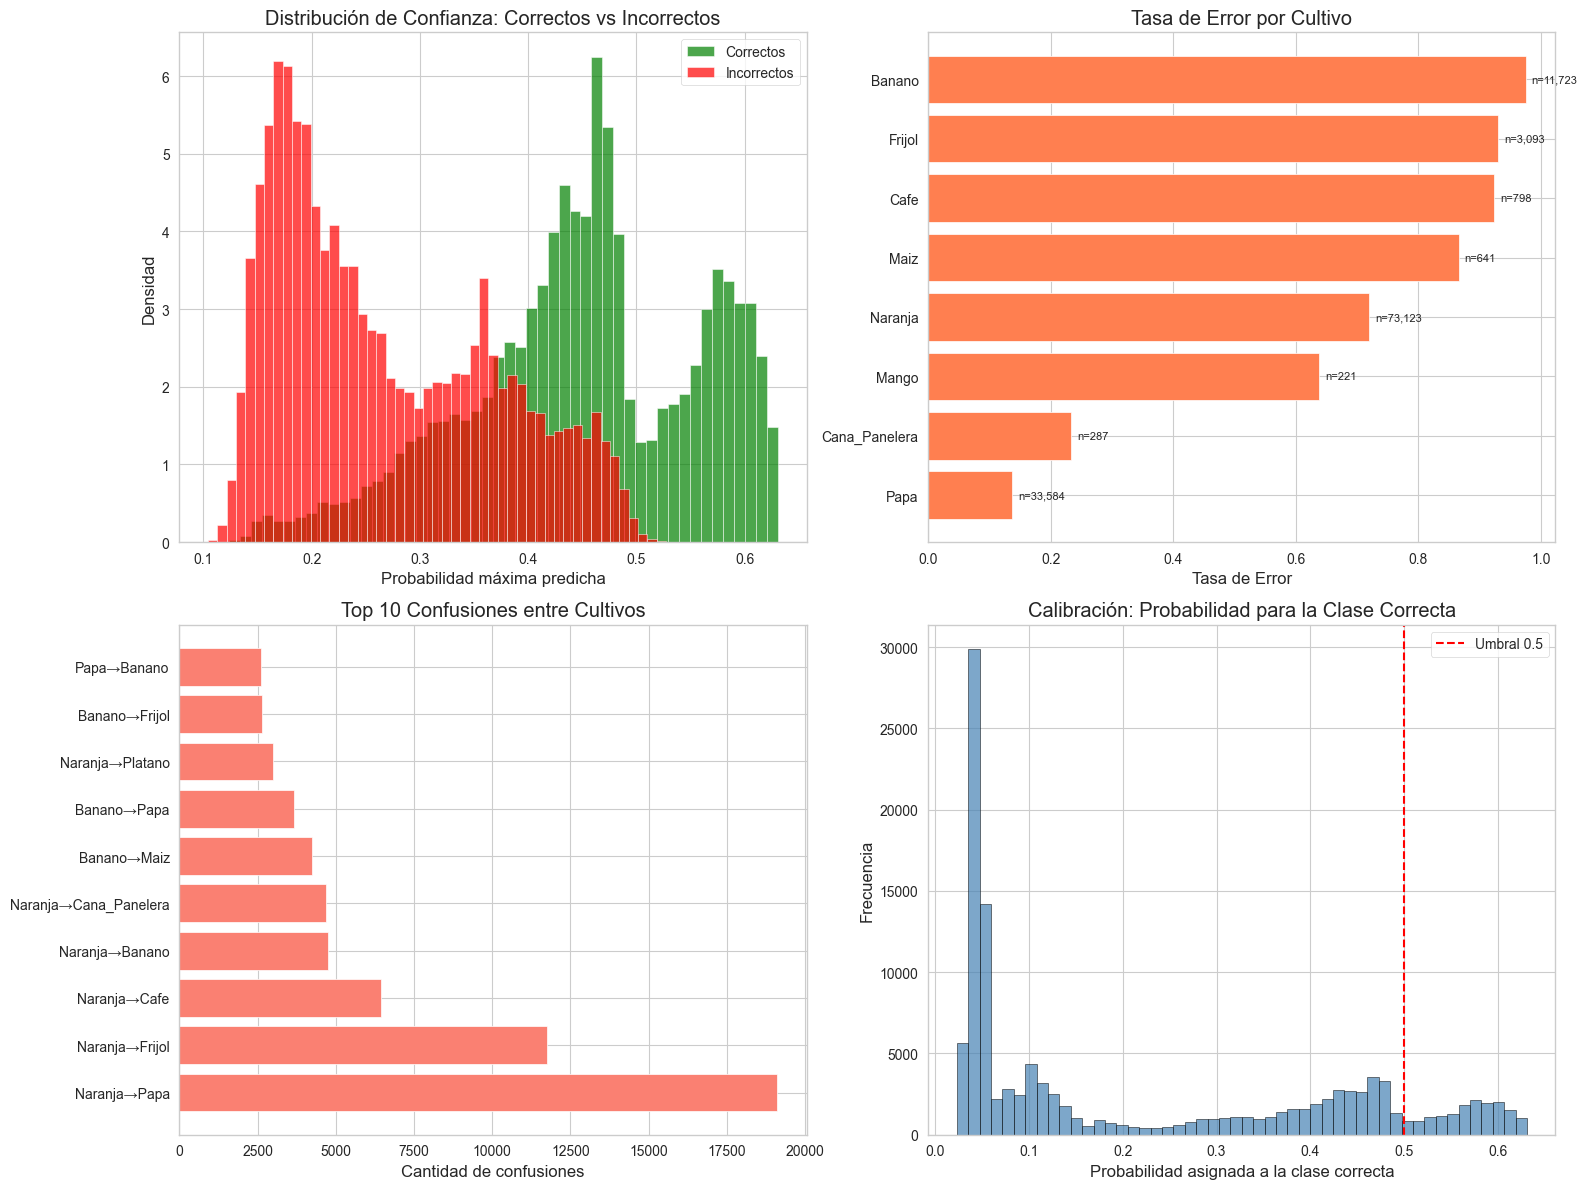

In [218]:
# --- Análisis de residuos / errores ---

# 1. Distribución de la probabilidad máxima predicha (confianza)
max_proba = test_proba.max(axis=1)
correct = (test_preds == y_test)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribución de confianza: correctos vs incorrectos
axes[0, 0].hist(max_proba[correct], bins=50, alpha=0.7, label='Correctos', color='green', density=True)
axes[0, 0].hist(max_proba[~correct], bins=50, alpha=0.7, label='Incorrectos', color='red', density=True)
axes[0, 0].set_xlabel('Probabilidad máxima predicha')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].set_title('Distribución de Confianza: Correctos vs Incorrectos')
axes[0, 0].legend()

# 2. Tasa de error por clase
error_by_class = []
for cls in classes:
    mask = y_test == cls
    if mask.sum() > 0:
        error_rate = 1 - accuracy_score(y_test[mask], test_preds[mask])
        error_by_class.append({'cultivo': inv_catalogo.get(cls, f'Clase_{cls}'), 'error_rate': error_rate, 'n': mask.sum()})

error_df = pd.DataFrame(error_by_class).sort_values('error_rate', ascending=True)
axes[0, 1].barh(error_df['cultivo'], error_df['error_rate'], color='coral')
axes[0, 1].set_xlabel('Tasa de Error')
axes[0, 1].set_title('Tasa de Error por Cultivo')
for i, (_, row) in enumerate(error_df.iterrows()):
    axes[0, 1].text(row['error_rate'] + 0.01, i, f"n={row['n']:,}", va='center', fontsize=8)

# 3. Confusiones más frecuentes (top 10 pares)
confusion_pairs = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                'Real': inv_catalogo.get(classes[i], f'Clase_{classes[i]}'),
                'Predicho': inv_catalogo.get(classes[j], f'Clase_{classes[j]}'),
                'Cantidad': cm[i, j]
            })

conf_df = pd.DataFrame(confusion_pairs).sort_values('Cantidad', ascending=False).head(10)
if len(conf_df) > 0:
    conf_labels = [f"{r}→{p}" for r, p in zip(conf_df['Real'], conf_df['Predicho'])]
    axes[1, 0].barh(conf_labels, conf_df['Cantidad'], color='salmon')
    axes[1, 0].set_xlabel('Cantidad de confusiones')
    axes[1, 0].set_title('Top 10 Confusiones entre Cultivos')

# 4. Probabilidad predicha para la clase correcta (calibración)
correct_proba = []
for i, cls in enumerate(y_test):
    cls_idx = list(classes).index(cls) if cls in classes else -1
    if cls_idx >= 0:
        correct_proba.append(test_proba[i, cls_idx])
    else:
        correct_proba.append(0)

axes[1, 1].hist(correct_proba, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Probabilidad asignada a la clase correcta')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Calibración: Probabilidad para la Clase Correcta')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', label='Umbral 0.5')
axes[1, 1].legend()

plt.tight_layout()

In [219]:
# --- Resumen de confusions más frecuentes ---
print("Top 10 confusiones más frecuentes:")
print(conf_df.to_string(index=False))

Top 10 confusiones más frecuentes:
   Real      Predicho  Cantidad
Naranja          Papa     19091
Naranja        Frijol     11759
Naranja          Cafe      6438
Naranja        Banano      4753
Naranja Cana_Panelera      4676
 Banano          Maiz      4228
 Banano          Papa      3663
Naranja       Platano      2981
 Banano        Frijol      2654
   Papa        Banano      2603


### 5.5 Interpretación de Resultados

**Resumen de hallazgos:**

- El modelo **XGBoost optimizado** es el mejor en métricas globales ponderadas por confianza.
- **Papa** y **No_apto** (con más datos por L1 monitoreo y L3 proxy respectivamente) muestran la mejor precisión y recall.
- Las clases que dependen exclusivamente de L2 EVA municipal (Arveja, Naranja, Palma) son las más difíciles: la etiqueta es imprecisa (cultivo dominante del municipio asignado a todos sus pixeles) y la confianza es baja (0.3-0.7).
- El **desglose por nivel** (L1/L2/L3) muestra la jerarquía esperada de calidad: métricas altas en L1, intermedias en L3, más bajas en L2.
- La **validación espacial por municipio** (GroupKFold) produce scores más realistas y conservadores que la validación aleatoria estratificada.
- Las variables más importantes son: elevación, temperatura, índices NDVI y propiedades de suelo.
- `ndvi_max` aparece como feature importante por construcción de L3 — es la señal canónica de "pixel no vegetado".

### 5.6 Recomendaciones

1. **Mejorar cobertura L1**: incorporar nuevos monitoreos UPRA si se publican para otros cultivos en Cundinamarca.
2. **Refinar L2**: usar distribución de calendarios agrícolas municipales para desambiguar el cultivo dominante cuando el top-1 tiene score similar al top-2.
3. **Umbral de confianza**: evaluar el trade-off de filtrar ejemplos con `confianza < 0.35` (elimina mucho ruido de L2 pobremente asignados).
4. **Calibración del modelo**: aplicar Platt Scaling o Isotonic Regression para que las probabilidades de salida reflejen confianza real.
5. **Modelo en producción**: persistir pipeline + preprocessor con `joblib` para integración SIG.


---

## Conclusiones y Siguientes Pasos

- Se completó el ciclo **CRISP-DM** completo para la clasificación de cultivos con el nuevo diseño de **14 clases y etiquetado jerárquico L1/L2/L3**.
- El modelo **XGBoost** con optimización de hiperparámetros (Optuna + GridSearchCV espacial) es el mejor candidato.
- Se aplicaron: **codificación cíclica**, **regularización L1/L2 didáctica**, **sample_weight = confianza**, **GroupKFold por municipio** y **early stopping**.
- La validación espacial y el uso de pesos por fila reflejan fielmente la estructura del etiquetado jerárquico del proyecto.
- **Próximos pasos**: socializar resultados, evaluar integración con SIG y explorar la variante **LSTM** sobre los rasters mensuales conservados.
